In [5071]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import pingouin as pg

# 머신러닝 
from sklearn.model_selection import train_test_split

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [5072]:
df = pd.read_csv('./data/merged_data.csv')

In [5073]:
df2 = df.copy()

In [5074]:
# review_score 컬럼 결측치 제거
print(f"제거 전 데이터 개수: {len(df2)}")
df2 = df2.dropna(subset=['review_score']).reset_index()
print(f"제거 후 데이터 개수: {len(df2)}")

제거 전 데이터 개수: 96432
제거 후 데이터 개수: 95786


In [5075]:
# 파생 컬럼 생성
df2['order_purchase_timestamp'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['order_delivered_customer_date'] = pd.to_datetime(df2['order_delivered_customer_date'])
df2['order_estimated_delivery_date'] = pd.to_datetime(df2['order_estimated_delivery_date'])
df2['order_approved_at'] = pd.to_datetime(df2['order_approved_at'])
df2['order_delivered_carrier_date'] = pd.to_datetime(df2['order_delivered_carrier_date'])

# 주문 시점의 요일 정보 추가
df2['order_purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek
df2['order_purchase_dayofweek'] = df2['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
# 요일 순서 정의 
weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# 데이터를 범주형(Categorical)으로 변환하여 순서 부여
# 이렇게 하면 groupby를 해도 이 순서가 유지됨
df2['order_purchase_dayofweek'] = pd.Categorical(df2['order_purchase_dayofweek'], 
                                                categories=weekday_order, 
                                                ordered=True)

# 주문 시점의 월 정보 추가
df2['order_purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['order_purchase_month'] = df2['order_purchase_month'].astype('category')
df2['order_purchase_month'] = df2['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df2['order_purchase_month'] = df2['order_purchase_month'].cat.codes
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)
df2['order_purchase_month'] = df2['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)

# 주문 시점의 연도 정보 추가
df2['order_purchase_year'] = df2['order_purchase_timestamp'].dt.year
df2['order_purchase_year'] = df2['order_purchase_year'].astype(int)

df2.info()
df2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_city                  95786 non-null  str           
 10  customer_state                 95786 non-null  str           
 11  total_items_count         

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",housewares,maua,SP,monday,10,2017
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,Muito boa a loja,Muito bom o produto.,perfumery,belo horizonte,SP,tuesday,7,2018
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,NaN,NaN,auto,guariba,SP,wednesday,8,2018
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop,belo horizonte,MG,saturday,11,2017
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,NaN,NaN,stationery,mogi das cruzes,SP,tuesday,2,2018
5,5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,4.0,NaN,NaN,auto,guarulhos,SP,sunday,7,2017
6,6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,5.0,NaN,NaN,auto,atibaia,SP,tuesday,5,2017
7,7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05,1.0,NaN,NaN,furniture_decor,sao jose do rio pardo,SP,monday,1,2017
8,8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,299905e3934e9e181bfb2e164dd4b4f8,sorocaba,SP,1,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,149.99,19.77,5.0,NaN,NaN,office_furniture,itaquaquecetuba,SP,saturday,7,2017
9,9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:

In [5076]:
### 승인 소요 일수 계산 (order_approved_at - order_purchase_timestamp)
df2['approved_days'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['approved_days'] = df2['approved_days'].astype(int)

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df2['dispatch_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['dispatch_days'] = df2['dispatch_days'].astype(int)

### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['delivery_days'] = df2['delivery_days'].astype(int)

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df2['expected_delivery_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['expected_delivery_days'] = df2['expected_delivery_days'].astype(int)

### 지연 일수 계산 (order_delivered_customer_date - order_estimated_delivery_date)
# 지연된 것이 양수
df2['delay_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.total_seconds() / 86400
df2['delay_days'] = df2['delay_days'].round(1)
df2['delay_days_int'] = df2['delay_days'].astype(int)

### 지연 여부 (0 또는 1)
df2['is_delayed'] = (df2['delay_days'] > 0).astype(int)

In [5077]:
df2.head()

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",housewares,maua,SP,monday,10,2017,0,2,8,15,-7.1,-7,0
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,Muito boa a loja,Muito bom o produto.,perfumery,belo horizonte,SP,tuesday,7,2018,1,1,13,19,-5.4,-5,0
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,NaN,NaN,auto,guariba,SP,wednesday,8,2018,0,0,9,26,-17.2,-17,0
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop,belo horizonte,MG,saturday,11,2017,0,3,13,26,-13.0,-13,0
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,NaN,NaN,stationery,mogi das cruzes,SP,tuesday,2,2018,0,0,2,12,-9.2,-9,0


In [5078]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_city                  95786 non-null  str           
 10  customer_state                 95786 non-null  str           
 11  total_items_count         

In [5079]:
df2.isna().sum()

index                                0
order_id                             0
customer_id                          0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
total_items_count                    0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
review_score                         0
review_comment_title             84598
review_comment_message           56906
product_category_name_english     1370
seller_city                          0
seller_state                         0
order_purchase_dayofweek             0
order_purchase_month                 0
order_purchase_year      

### 이상치 처리
#### 출고일 < 0 행 제거

In [5080]:
# 이상치 처리 
data = df2[df2['dispatch_days'] < 0].copy() 
data

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
24963,25111,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,faed38109bbf7da6f035630d92a49a27,sao paulo,SP,1,9070fbe936bd54b8a72e0ffe4a6a2564,89de2d6f23e9746ff309705b23581faa,2018-07-20 18:50:22,40.0,14.58,5.0,NaN,NaN,books_technical,londrina,PR,monday,7,2018,0,-171,7,21,-14.2,-14,0
80252,80782,4021cd7611d6d9ce5ffcd24817fc374f,ac27243bffbc9c58eb62adfb58c71488,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,2018-08-30,216dc3bc64c10494ca97500c2a6b658f,indaiatuba,SP,1,98e55bdc6487be7b8c32b0eb689dcb8a,4a23adac87cf538689fa600d976f78b2,2018-08-23 12:10:30,135.0,8.21,4.0,NaN,NaN,furniture_decor,sao paulo,SP,saturday,8,2018,0,-4,10,11,-0.8,0,0


In [5081]:
print(f"이상치 제거 전 행 수 : {len(df2)}")
df2 = df2[df2['dispatch_days'] >= 0].copy()
print(f"이상치 제거 후 행 수 : {len(df2)}")

이상치 제거 전 행 수 : 95786
이상치 제거 후 행 수 : 95784


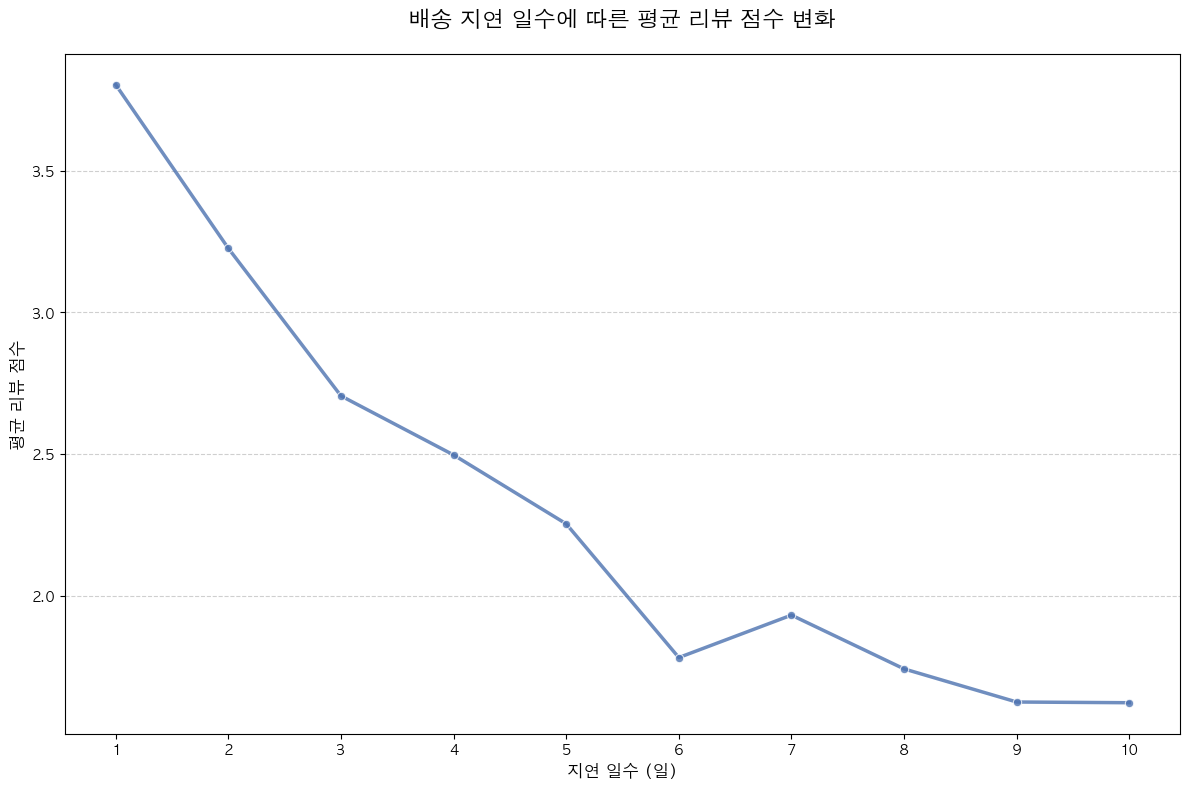

In [5082]:
# delay_days 가 x축, review_score 가 y축 --> 꺾은선 그래프 line plot

plt.figure(figsize=(12, 8))

# 1. 데이터 준비 (지연 1~10일 데이터만 필터링 및 평균 계산)
data_filtered = df2[(df2['delay_days_int'] > 0) & (df2['delay_days_int'] <= 10)].copy()
plot_data = data_filtered.groupby('delay_days_int')['review_score'].mean().reset_index()

# 2. 꺾은선 그래프 그리기
sns.lineplot(
    data=plot_data, 
    x='delay_days_int', 
    y='review_score', 
    marker='o',        
    color="#4C72B0",   
    linewidth=2.5, 
    alpha=0.8
)

# 3. 그래프 스타일링 (가독성 향상)
plt.title('배송 지연 일수에 따른 평균 리뷰 점수 변화', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지연 일수 (일)', fontsize=12)
plt.ylabel('평균 리뷰 점수', fontsize=12)
plt.xticks(range(1, 11))  # x축 눈금을 1일 단위로 표시
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # 가로 그리드 추가

plt.tight_layout()
plt.show()

위의 꺾은선 그래프를 보아 지연일이 3일, 6일, 9일인 지점에서 큰 변화가 일어난다고 보여져서 기준을 3일, 6일, 9일으로 잡았다

In [5083]:
# delay_days를 카테고리화
def delay_days_cat(x):
    if x < 0:
         return '조기'
    elif x == 0:
         return '정시'
    elif x <= 3: 
        return '1-3일 지연'
    elif x <= 6: 
        return '4-6일 지연'
    elif x <= 9:
        return '7-9일 지연'
    else: 
        return '10일 이상 지연'

df2['delay_days_cat'] = df2['delay_days'].apply(delay_days_cat)

In [5084]:
df2['delay_days_cat'].value_counts()

delay_days_cat
조기           88010
1-3일 지연       2591
10일 이상 지연     2435
4-6일 지연       1374
7-9일 지연       1199
정시             175
Name: count, dtype: int64

In [5085]:
df2.info()

<class 'pandas.DataFrame'>
Index: 95784 entries, 0 to 95785
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95784 non-null  int64         
 1   order_id                       95784 non-null  str           
 2   customer_id                    95784 non-null  str           
 3   order_purchase_timestamp       95784 non-null  datetime64[us]
 4   order_approved_at              95784 non-null  datetime64[us]
 5   order_delivered_carrier_date   95784 non-null  datetime64[us]
 6   order_delivered_customer_date  95784 non-null  datetime64[us]
 7   order_estimated_delivery_date  95784 non-null  datetime64[us]
 8   customer_unique_id             95784 non-null  str           
 9   customer_city                  95784 non-null  str           
 10  customer_state                 95784 non-null  str           
 11  total_items_count              

In [5086]:
df2['review_score'].value_counts()

review_score
5.000000    56682
4.000000    18859
1.000000     9304
3.000000     7911
2.000000     2912
4.500000       53
2.500000       30
3.500000       23
1.500000        8
3.333333        1
4.333333        1
Name: count, dtype: int64

In [5087]:
cols = df2.columns
cols

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_items_count', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat'],
      dtype='str')

In [5088]:
# train / test / validation split 

X = df2[cols]
y = df2['review_score']

# Train+Valid / Test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

### 본격적인 EDA 시작

In [5089]:
print(f"test 셋 분리 전 df : {len(df2)}")
df2 = X_train_valid.copy()
print(f"test 셋 분리 후 df : {len(df2)}")

test 셋 분리 전 df : 95784
test 셋 분리 후 df : 76627


In [5090]:
df2.to_csv('./data/merged_train_data.csv', index=False)

In [5091]:
95784*0.8 # 76627.2

76627.2

In [5092]:
df2['review_score'].value_counts()

review_score
5.000000    45287
4.000000    15084
1.000000     7519
3.000000     6346
2.000000     2291
4.500000       44
2.500000       25
3.500000       22
1.500000        8
3.333333        1
Name: count, dtype: int64

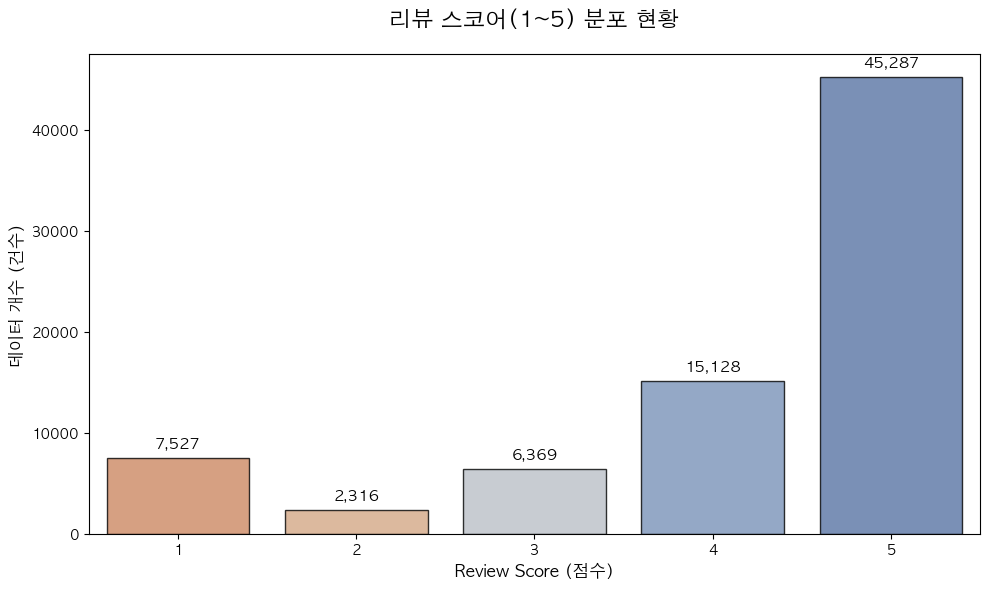

In [5093]:
# 1. 폰트 및 스타일 설정 (Mac 환경 기준)
plt.rc('font', family='AppleGothic') 
plt.figure(figsize=(10, 6))

# 2. 데이터 전처리 (리뷰 점수 정수화)
df2['review_score'] = df2['review_score'].astype(int)

# 3. 각 점수(1~5)에 매칭될 색상 딕셔너리 정의
# 낮은 점수는 오렌지 계열(#DD8452), 높은 점수는 블루 계열(#4C72B0)
score_palette = {
    1: "#DD8452", # 매우 낮음 (오렌지)
    2: "#E1A679", # 낮음 (연한 오렌지)
    3: "#B9C0C9", # 보통 (회색/중립)
    4: "#7091C2", # 높음 (연한 블루)
    5: "#4C72B0"  # 매우 높음 (딥 블루)
}

# 4. 그래프 그리기
sns.countplot(
    data=df2, 
    x='review_score', 
    palette=score_palette, 
    hue='review_score',
    legend=False,   
    edgecolor="black",
    alpha=0.8   
)

# 5. 세부 디자인 설정
plt.title('리뷰 스코어(1~5) 분포 현황', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Review Score (점수)', fontsize=12)
plt.ylabel('데이터 개수 (건수)', fontsize=12)

# 각 막대 위에 실제 빈도수(숫자) 표시
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0: # 데이터가 있는 경우만 표시
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

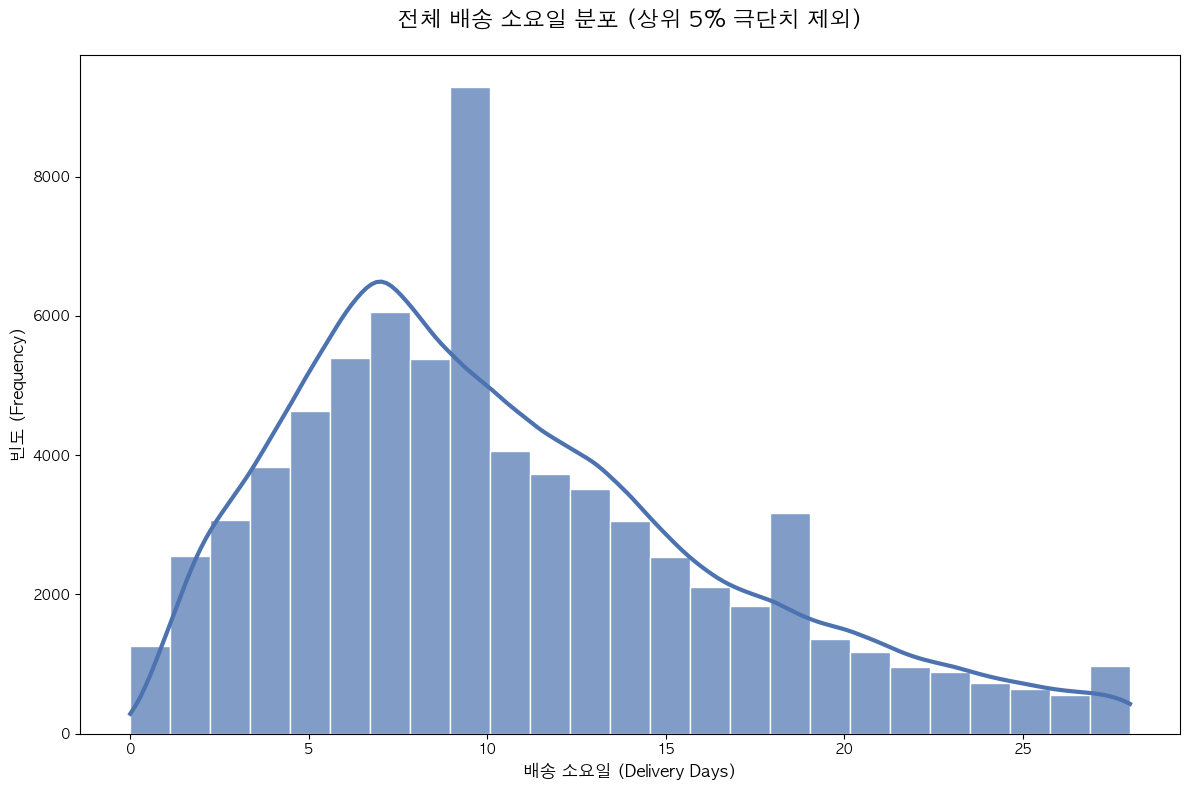

In [5094]:
# 1. 스타일 및 폰트 설정
plt.rc('font', family='AppleGothic') # Mac 기준
plt.figure(figsize=(12, 8))

# 2. 데이터 필터링 (상위 5% 극단치 제외)
delivery_data = df2[df2['delivery_days'] < df2['delivery_days'].quantile(0.95)]['delivery_days']

# 3. 히스토그램 그리기
sns.histplot(
    delivery_data, 
    bins=25, 
    color='#4C72B0',    
    kde=True,            # 밀도 곡선 추가
    line_kws={'linewidth': 3}, 
    edgecolor='white',   # 막대 사이 구분선 추가
    alpha=0.7            # 막대 투명도 조절
)

# 4. 세부 디자인 설정
plt.title('전체 배송 소요일 분포 (상위 5% 극단치 제외)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('배송 소요일 (Delivery Days)', fontsize=12)
plt.ylabel('빈도 (Frequency)', fontsize=12)

plt.tight_layout()
plt.show()

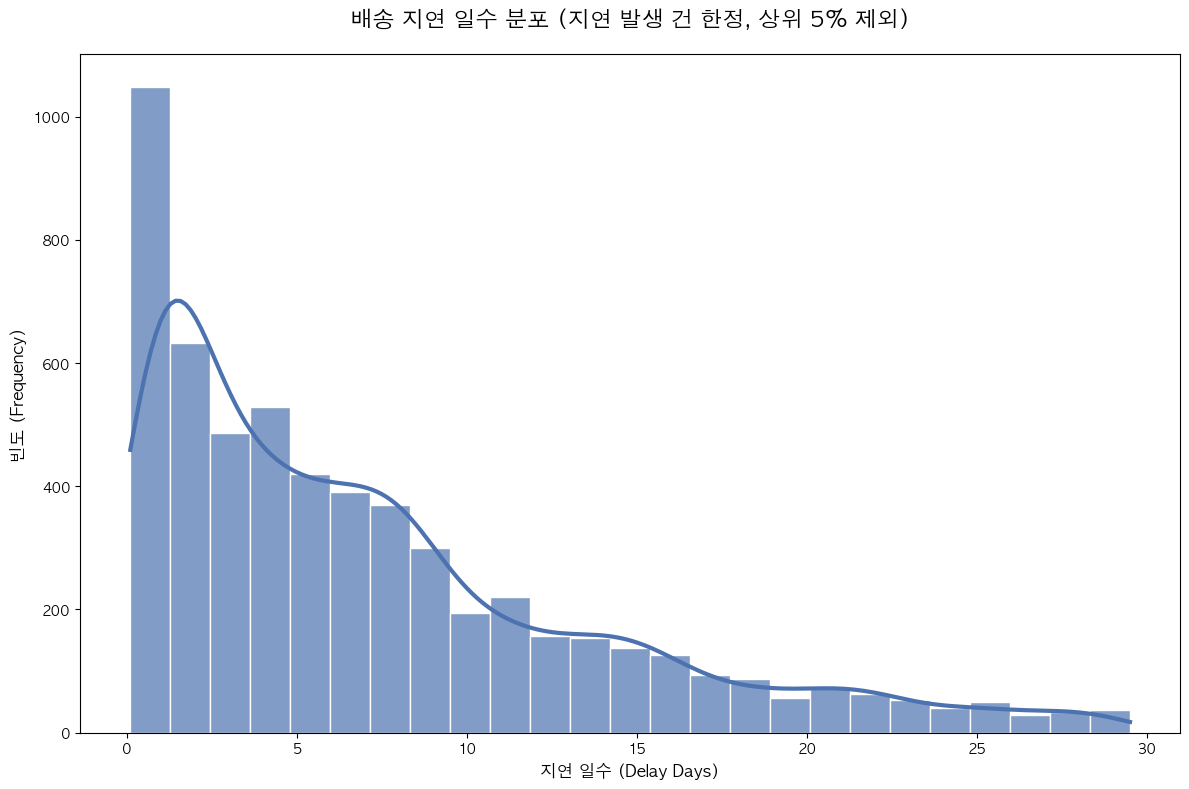

In [5095]:
# --- 시각화 ---
# 1. 스타일 및 폰트 설정
plt.rc('font', family='AppleGothic') 
plt.figure(figsize=(12, 8))

# 2. 데이터 필터링: 지연된 건(양수) 중 상위 5% 극단치 제외
delayed_df = df2[df2['delay_days'] > 0]
plot_data = delayed_df[delayed_df['delay_days'] < delayed_df['delay_days'].quantile(0.95)]['delay_days']

# 3. 히스토그램 그리기
sns.histplot(
    plot_data, 
    bins=25, 
    color='#4C72B0',   
    kde=True,   
    line_kws={'linewidth': 3}, 
    edgecolor='white', 
    alpha=0.7
)

# 4. 세부 디자인 설정
plt.title('배송 지연 일수 분포 (지연 발생 건 한정, 상위 5% 제외)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지연 일수 (Delay Days)', fontsize=12)
plt.ylabel('빈도 (Frequency)', fontsize=12)

plt.tight_layout()
plt.show()

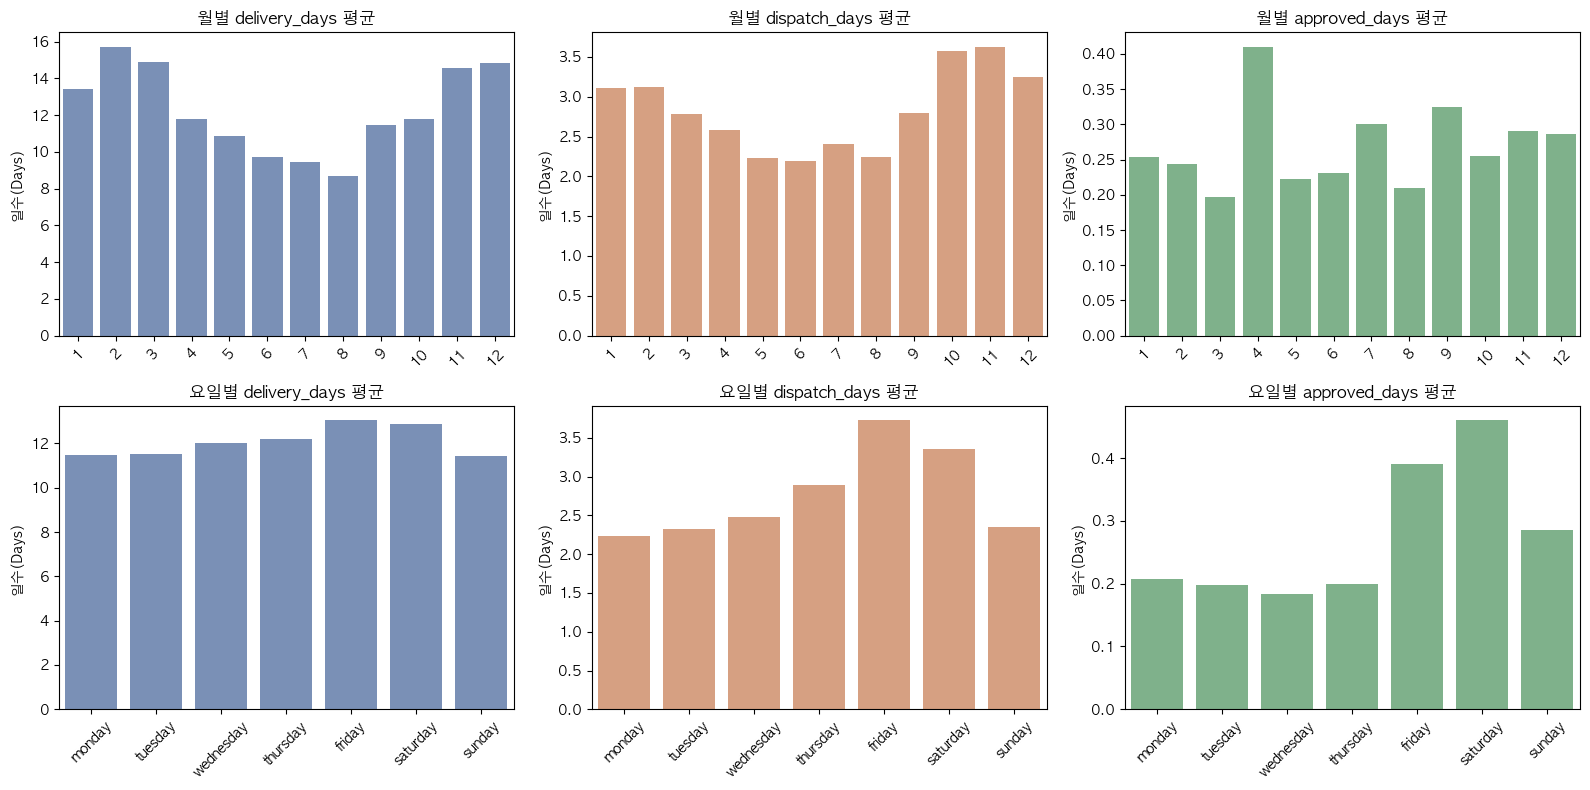

In [5096]:
# 월별, 요일별 주요 일수 추이 비교

# 2x4 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

days = ['delivery_days','dispatch_days','approved_days']
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, day in enumerate(days):
    ax1 = axes[0][i]
    ax2 = axes[1][i]

    monthly = df2.groupby('order_purchase_month')[day].mean().reset_index()
    daily = df2.groupby('order_purchase_dayofweek')[day].mean().reset_index()

    # 월별 막대 그래프
    sns.barplot(data=monthly, x='order_purchase_month', y=day,
                ax=ax1, color=colors[i], alpha=0.8)
    
    # 요일별 막대 그래프
    sns.barplot(data=daily, x='order_purchase_dayofweek', y=day,
                ax=ax2, color=colors[i], alpha=0.8)
    
    # 타이틀 및 라벨 설정
    ax1.set_title(f"월별 {day} 평균")
    ax2.set_title(f"요일별 {day} 평균")
    for ax in [ax1, ax2]:
        ax.set_xlabel("") # x라벨 중복 제거
        ax.set_ylabel("일수(Days)")
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


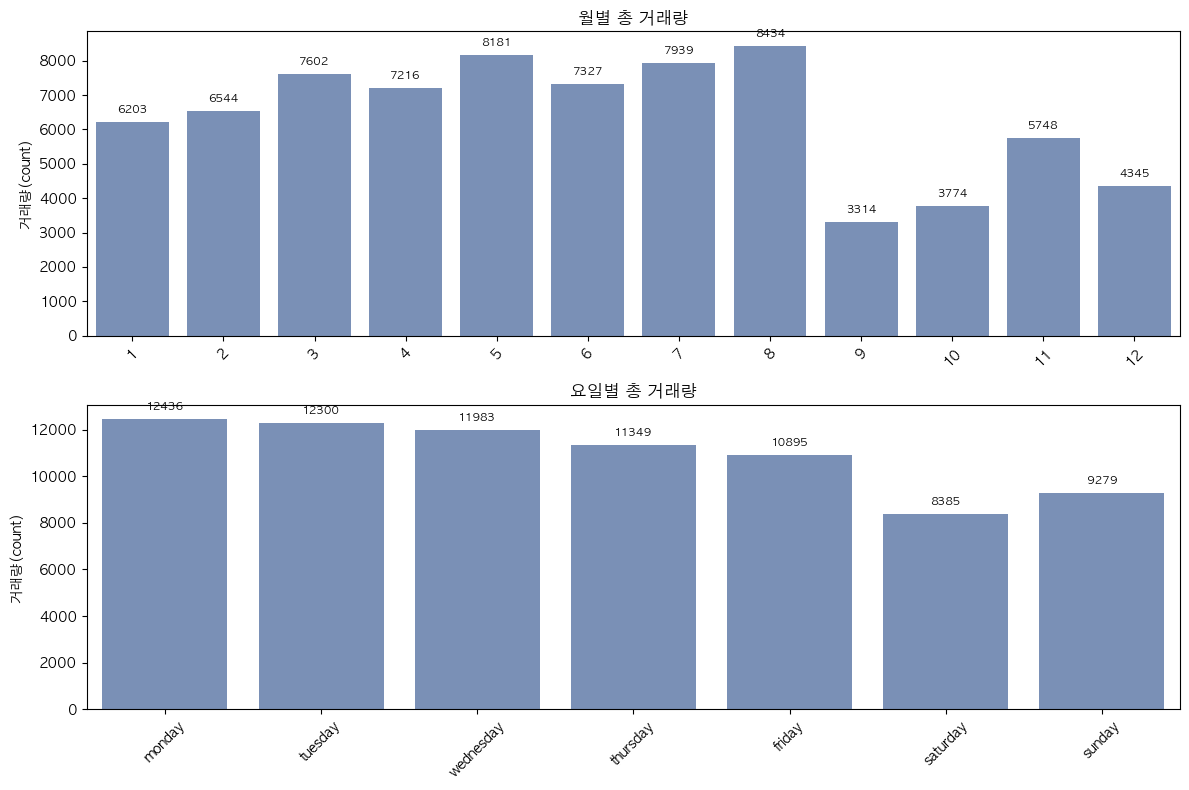

In [5097]:
# 월별 거래량

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

monthly = df2.groupby('order_purchase_month').size().reset_index(name='count')
daily = df2.groupby('order_purchase_dayofweek').size().reset_index(name='count')

# 월별 막대 그래프
sns.barplot(data=monthly, x='order_purchase_month', y='count', 
            ax=axes[0], color="#4C72B0", alpha=0.8)
axes[0].set_title(f"월별 총 거래량")
    
# 요일별 막대 그래프
sns.barplot(data=daily, x='order_purchase_dayofweek', y='count',
                ax=axes[1], color="#4C72B0", alpha=0.8)
axes[1].set_title(f"요일별 총 거래량")
    
for ax in [axes[0], axes[1]]:
    ax.set_xlabel("")
    ax.set_ylabel("거래량(count)")
    ax.tick_params(axis='x', rotation=45)
# 막대 상단에 숫자 표시 (선택 사항)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=8)

plt.tight_layout()
plt.show()

Carnival (Feb 14-17), New Year's Day (Jan 1), Independence Day (Sept 7), and Christmas (Dec 25)

- 월별로 배송에 걸리는 일수 (delivery_days : Delivered - Purchase) 를 확인했을 때 1,2,3,11,12월에 배송소요일이 크게 나오고, 6,7,8월에 배송소요일이 적게 나온다
- 이는 계절성과 관련이 있지않을까?
- 월별 거래량을 확인했을 때에도 오히려 배송소요일이 크게 나온 달보다 배송소요일이 적게 나온 달의 월별 거래량이 크게 나왔기 때문에 거래량으로 인한 배송지연은 아니라고 보여진다
- 브라질은 가톨릭 신자가 많아 크리스마스에 성대한 기념 행사가 일어나는데 이와 관련하여 12월에 배송지연이 많이 발생하는것 아닐까?
- 또한 2월 즈음에도 '카니발'이라는 중요한 축제도 열리기 때문에 이러한 연휴가 주로 껴있는 연말,연초에 배송이 오래 걸리고 이는 결국 거래량과는 무관하다고 보여진다

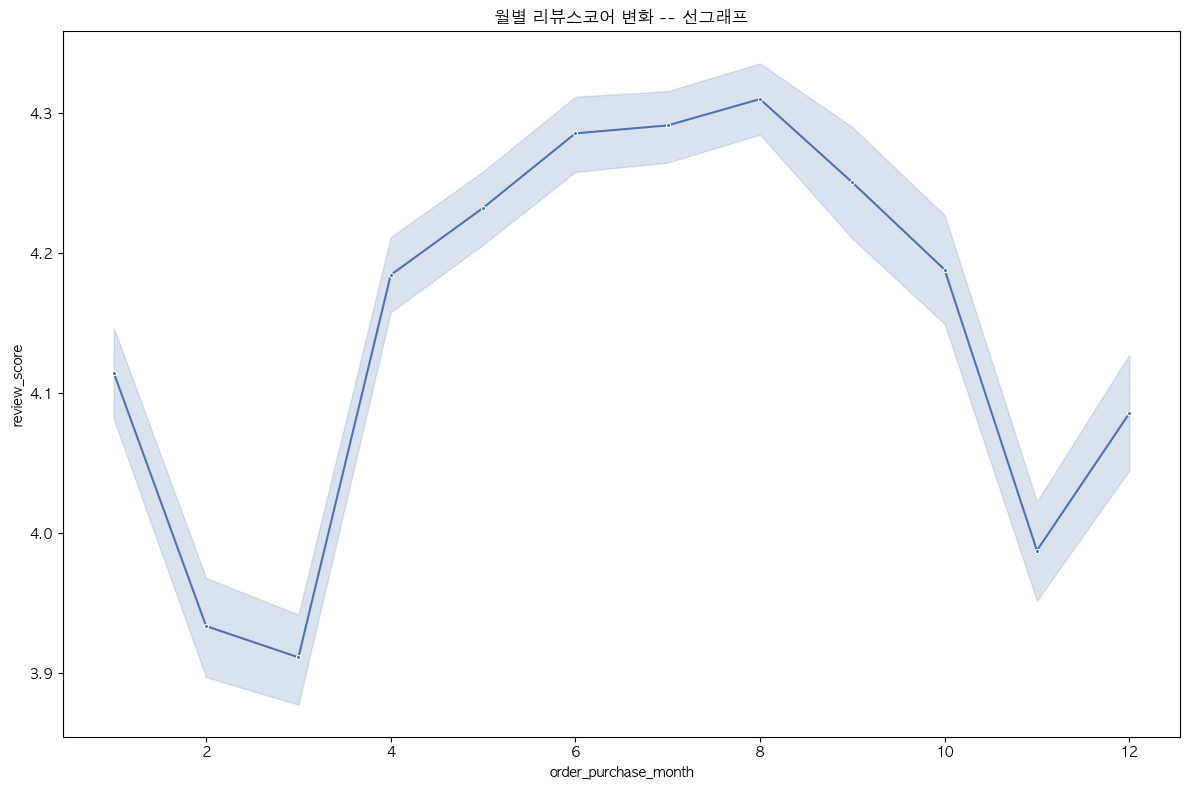

In [5098]:
# 월별 리뷰스코어 변화 -- 선그래프 
plt.figure(figsize=(12, 8))
sns.lineplot(data=df2, x='order_purchase_month', y='review_score', 
                 color="#4C72B0", marker='o', markersize=3, errorbar=('ci', 95))
plt.title("월별 리뷰스코어 변화 -- 선그래프")
plt.tight_layout()
plt.show()

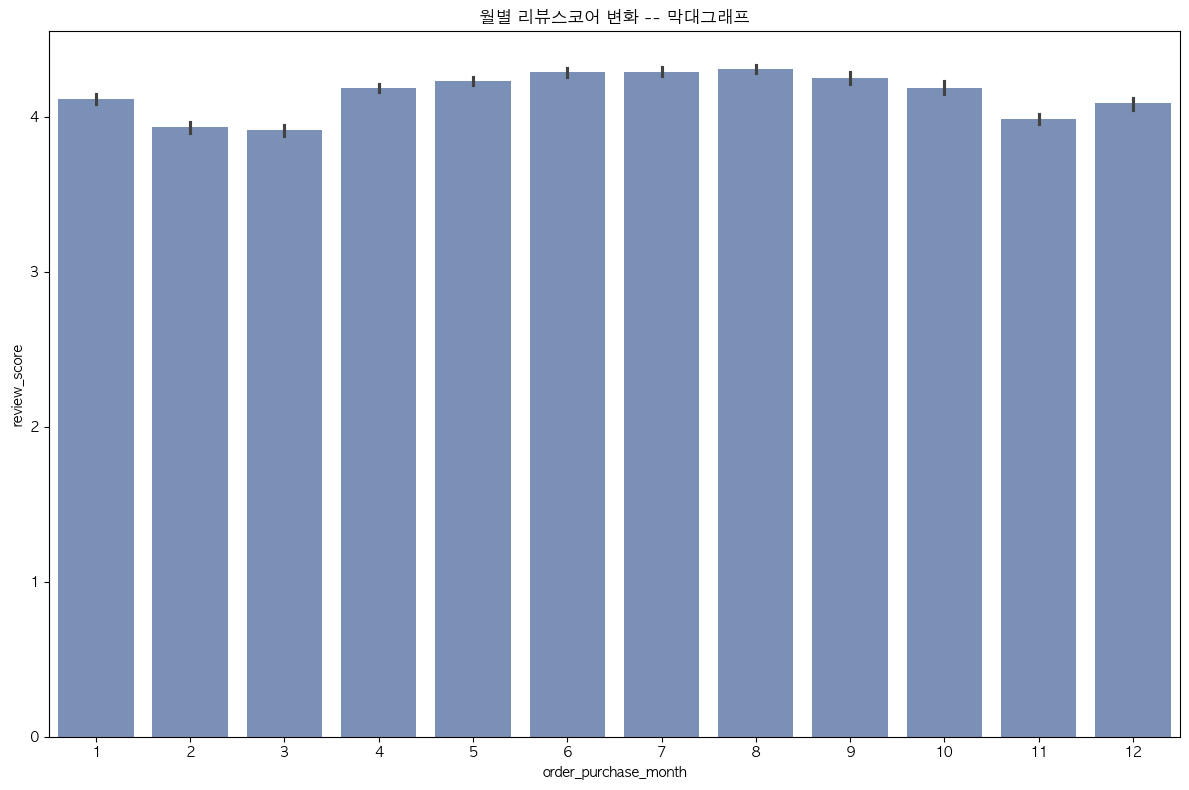

In [5099]:
# 월별 리뷰스코어 변화 -- 막대그래프 
plt.figure(figsize=(12, 8))
sns.barplot(data=df2, x='order_purchase_month', y='review_score', 
                 color="#4C72B0", alpha=0.8)
plt.title("월별 리뷰스코어 변화 -- 막대그래프")
plt.tight_layout()
plt.show()

월별 delivery_days가 차이가 나서 이에 따른 월별 review_score 또한 특징적인 추이가 나타날까 궁금하여 lineplot과 barplot을 그려보았지만, 

사실상 눈에 띄는 변화는 보이지 않았음

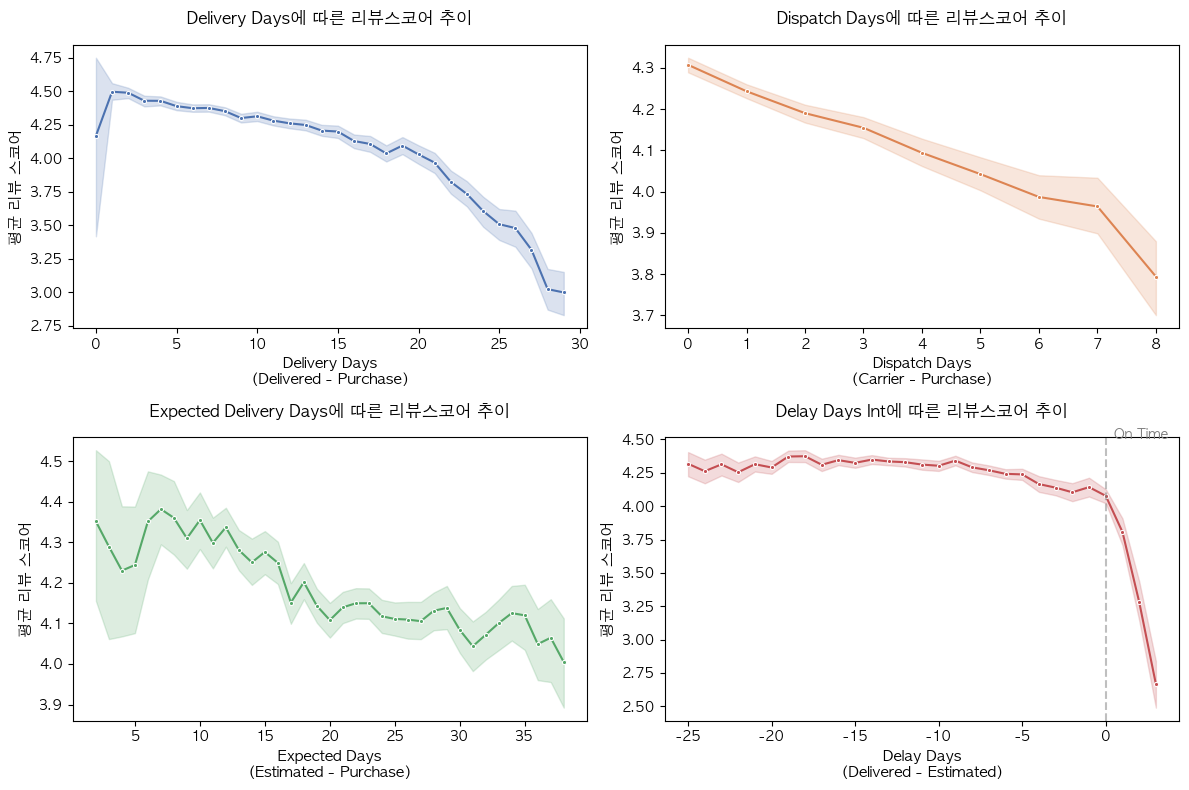

In [5100]:
# 배송 소요 일수에 따른 리뷰 스코어 변화

# 1. 시각화 대상 컬럼과 수식 정의
plot_info = [
    {'col': 'delivery_days', 'label': 'Delivery Days\n(Delivered - Purchase)', 'color': '#4C72B0'},
    {'col': 'dispatch_days', 'label': 'Dispatch Days\n(Carrier - Purchase)', 'color': '#DD8452'},
    {'col': 'expected_delivery_days', 'label': 'Expected Days\n(Estimated - Purchase)', 'color': '#55A868'},
    {'col': 'delay_days_int', 'label': 'Delay Days\n(Delivered - Estimated)', 'color': '#C44E52'}
]

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, info in enumerate(plot_info):
    col = info['col']
   
    # 너무 적은 샘플(롱테일)로 인한 왜곡 방지를 위해 상위 95% 구간까지만 시각화 (이상치 제외)
    upper_limit = df2[col].quantile(0.95)
    lower_limit = df2[col].quantile(0.05) if col == 'delay_days_int' else 0
    plot_data = df2[(df2[col] >= lower_limit) & (df2[col] <= upper_limit)]
    
    # 일수별 평균 리뷰 점수 시각화 (신뢰구간 포함)
    sns.lineplot(data=plot_data, x=col, y='review_score', 
                 ax=axes[i], color=info['color'], marker='o', markersize=3, errorbar=('ci', 95))
    
    # 타이틀 및 축 라벨 설정 (수식 포함)
    axes[i].set_title(f"{col.replace('_', ' ').title()}에 따른 리뷰스코어 추이", fontsize=12, fontweight='bold', pad=15)
    axes[i].set_xlabel(info['label'], fontsize=11, fontweight='semibold')
    axes[i].set_ylabel("평균 리뷰 스코어", fontsize=11)
    
    # 0점 기준선 (delivery_error_days의 경우 지연 여부 판단 기준)
    if col == 'delay_days_int':
        axes[i].axvline(0, color='gray', linestyle='--', alpha=0.5)
        axes[i].text(0.5, 4.5, 'On Time', color='gray', fontsize=10)

plt.tight_layout()
plt.show()


확실히 배송소요일이 오래 걸리거나 지연이 발생하면 리뷰스코어에 크게 타격이 있는 것으로 보여짐

(delivery_days & delay_days 그래프 확인)

따라서 상관관계를 파악해보기로 함

[delivery_days]
- 스피어만 상관계수: -0.236
- 유의성(P-value): 0.0000e+00
- 해석: 약한 정도의 음의 상관관계

[dispatch_days]
- 스피어만 상관계수: -0.109
- 유의성(P-value): 2.6974e-202
- 해석: 약한 정도의 음의 상관관계

[approved_days]
- 스피어만 상관계수: -0.013
- 유의성(P-value): 1.9360e-04
- 해석: 약한 정도의 음의 상관관계

[expected_delivery_days]
- 스피어만 상관계수: -0.057
- 유의성(P-value): 4.6376e-56
- 해석: 약한 정도의 음의 상관관계

[delay_days]
- 스피어만 상관계수: -0.177
- 유의성(P-value): 0.0000e+00
- 해석: 약한 정도의 음의 상관관계



<Figure size 1200x1000 with 0 Axes>

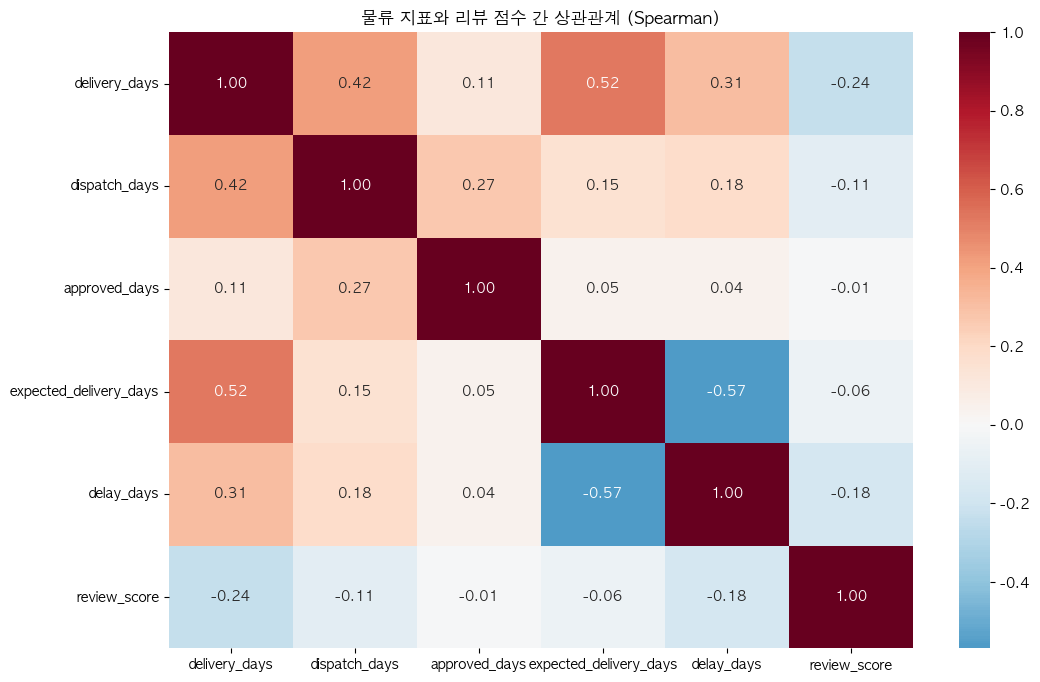

In [5101]:
# 배송 소요 일수 포함 주요 일수 컬럼과 리뷰 스코어의 상관관계

# 피어슨은 선형관계를 측정하는데 현 데이터는 선형성을 측정하는 것이 적절하지 않음
# '경향성'을 파악하고 범주형(순서형) 데이터의 rank를 측정할 땐 스피어만이 더 적절함

# 1. 상관관계 분석 대상에서 타겟 변수 분리
features = ['delivery_days', 'dispatch_days', 'approved_days', 'expected_delivery_days', 'delay_days']
target = 'review_score'

for day in features:
    valid_df = df2[[day, target]]
    
    if not valid_df.empty:
        # Spearman 산출 및 P-value 검정
        corr, p_value = stats.spearmanr(valid_df[day], valid_df[target])
        
        print(f"[{day}]")
        print(f"- 스피어만 상관계수: {corr:.3f}")
        print(f"- 유의성(P-value): {p_value:.4e}")
        
        # 해석 가이드 추가
        strength = "강한" if abs(corr) > 0.5 else "중간" if abs(corr) > 0.3 else "약한"
        sign = "음" if corr < 0 else "양" 
        print(f"- 해석: {strength} 정도의 {sign}의 상관관계\n")

# 3. 히트맵 시각화
plt.figure(figsize=(12, 10))

plt.figure(figsize=(12, 8))
sns.heatmap(df2[features + [target]].corr(method='spearman'), 
            annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("물류 지표와 리뷰 점수 간 상관관계 (Spearman)")
plt.show()

[delivery_days] -0.235

[dispatch_days] -0.108

[approved_days] -0.015

[expected_delivery_days] -0.056

[delay_days] -0.177

- 배송 소요일(delivery_days)은 review score와의 상관관계를 측정해보았을 때 -0.235로 약한 정도의 음의 상관관계를 보였다 
- 또한 지연일이나 출고를 하는데까지 걸린 시간보다 배송소요일 자체가 review score와 조금 더 강한 상관관계를 보임을 알 수 있다
- 이는 지연이 얼마나 되었는지나, 출고될 때까지 걸린 시간보다는 배송에 얼마나 소요되었는지가 더 영향력이 강함을 나타낸다

위에서 지연이 얼마나 되었는지보다 배송소요일이 review score에 더 강한 음의 상관관계를 보인다고 했는데 

그렇다면 지연이 되었는지의 여부 자체가 review score에 부정적인 영향을 끼치는지 확인해보고자 하였다.

### 정규성 검정 (qq-plot + shapiro 검정) --> welch's vs mannwhitney u 

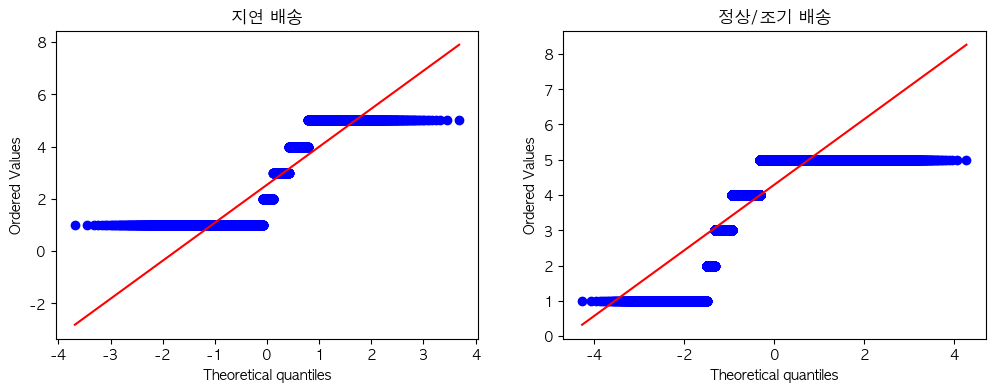

In [5102]:
# 그룹 나누기 (지연 O vs 지연 X)
delayed = df2[df2['is_delayed'] == 1]['review_score']
not_delayed = df2[df2['is_delayed'] == 0]['review_score']

# 두 그룹의 정규성 검정을 위한 q-q plot 시각화
fig, ax = plt.subplots(1,2, figsize=(12,4))
stats.probplot(delayed, plot=ax[0])
ax[0].set_title("지연 배송")
stats.probplot(not_delayed, plot=ax[1])
ax[1].set_title("정상/조기 배송")
plt.show()

In [5103]:
# shapiro 검정
stat_d, p_d = stats.shapiro(delayed)
stat_nd, p_nd = stats.shapiro(not_delayed)
print(f"지연 배송의 p-value : {p_d}") # 3.763957762774174e-68
print(f"정상/조기 배송의 p-value : {p_nd}") # 8.64438644798928e-140

print("두 그룹 모두 p-value가 0.05 미만이므로 정규성을 기각한다!")
print("따라서 비모수 검정인 Mannwhitney-U검정을 시행한다")

지연 배송의 p-value : 3.763957762774174e-68
정상/조기 배송의 p-value : 8.64438644798928e-140
두 그룹 모두 p-value가 0.05 미만이므로 정규성을 기각한다!
따라서 비모수 검정인 Mannwhitney-U검정을 시행한다


=== 배송 지연에 따른 리뷰 스코어 분석 결과 ===
정상/조기 배송 (0) 평균 점수: 4.29점 (데이터: 70,542건)
지연 배송 (1) 평균 점수: 2.54점 (데이터: 6,085건)
두 그룹의 평균 점수 차이: 1.75점

집단 간 차이 유의성 (p-value): 0.0000e+00
=> 결론: P-value가 0.05보다 작으므로, 배송 지연 여부에 따른 리뷰 점수 차이는 통계적으로 유의미하다


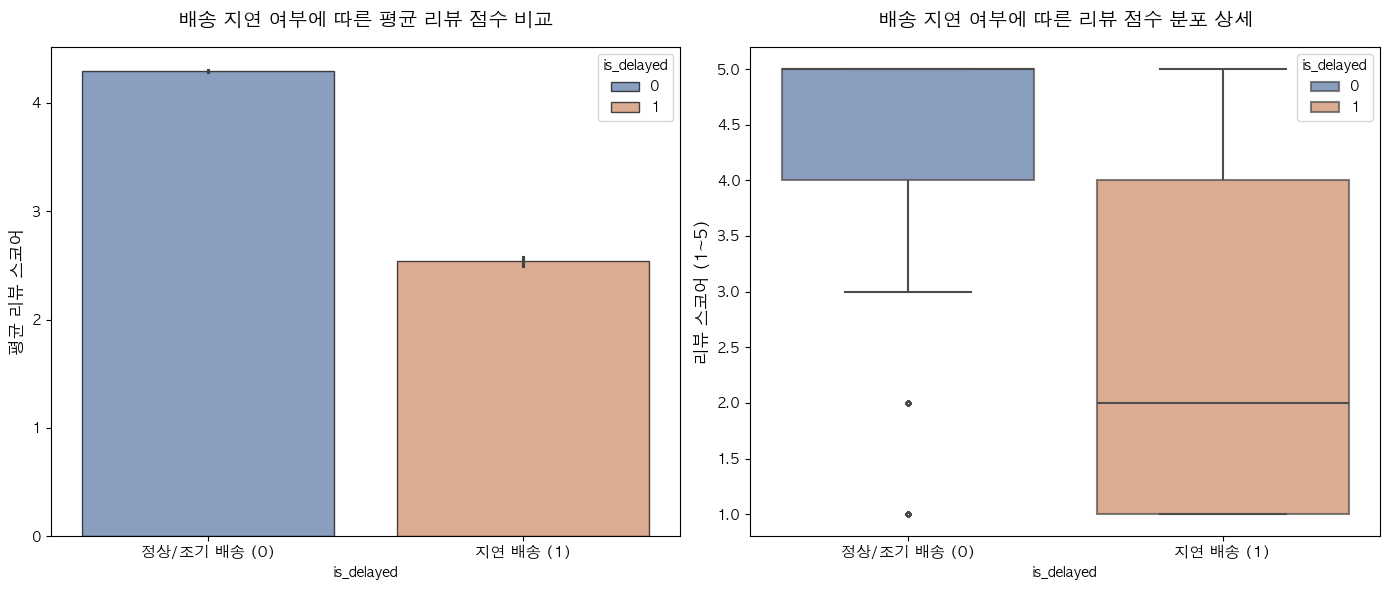

In [5104]:
print("=== 배송 지연에 따른 리뷰 스코어 분석 결과 ===")
print(f"정상/조기 배송 (0) 평균 점수: {not_delayed.mean():.2f}점 (데이터: {len(not_delayed):,}건)")
print(f"지연 배송 (1) 평균 점수: {delayed.mean():.2f}점 (데이터: {len(delayed):,}건)")
print(f"두 그룹의 평균 점수 차이: {not_delayed.mean() - delayed.mean():.2f}점")

# 지연 여부에 따른 평균 리뷰 점수 차이 확인 (Mann-Whitney U test)

u_stat, p_val = stats.mannwhitneyu(delayed, not_delayed)
print(f"\n집단 간 차이 유의성 (p-value): {p_val:.4e}")
if p_val < 0.05:
    print("=> 결론: P-value가 0.05보다 작으므로, 배송 지연 여부에 따른 리뷰 점수 차이는 통계적으로 유의미하다")
else:
    print("=> 결론: 통계적으로 유의미한 차이가 없다")

# --- 시각화 (컬러 변경 버전) ---
# 1. 커스텀 팔레트 정의 (0: 블루, 1: 오렌지)
my_palette = {0: "#4C72B0", 1: "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 가로 크기를 살짝 키워 여유 배치

# [왼쪽] 평균 점수 Barplot
# palette 매개변수에 커스텀 팔레트 딕셔너리를 직접 전달합니다.
sns.barplot(
    data=df2, 
    x='is_delayed', 
    y='review_score', 
    ax=axes[0], 
    palette=my_palette,
    hue='is_delayed',
    edgecolor="black",
    alpha=0.7
)

axes[0].set_title('배송 지연 여부에 따른 평균 리뷰 점수 비교', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'], fontsize=11)
axes[0].set_ylabel('평균 리뷰 스코어', fontsize=12)

# [오른쪽] 점수 분포 Boxplot
sns.boxplot(
    data=df2, 
    x='is_delayed', 
    y='review_score', 
    ax=axes[1], 
    palette=my_palette,
    hue='is_delayed',
    linewidth=1.5,
    boxprops={'alpha': 0.7},
    fliersize=3 # 아웃라이어 크기 조절
)

axes[1].set_title('배송 지연 여부에 따른 리뷰 점수 분포 상세', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'], fontsize=11)
axes[1].set_ylabel('리뷰 스코어 (1~5)', fontsize=12)

plt.tight_layout()
plt.show()

In [5105]:
# 비모수 효과크기 rank-biserial correlation
r_rb = pg.mwu(delayed, not_delayed)
display(r_rb)

# U_val	alternative	p_val	RBC	CLES
# MWU	94115675.0	two-sided	0.0	-0.561486	0.219257

# 효과크기 해석 기준 반영
def interpret_rbc(rbc):
    abs_rbc = abs(rbc)
    if abs_rbc < 0.1: return "심지어 무시할 만한 수준 (Negligible)"
    elif abs_rbc < 0.3: return "작은 수준 (Small)"
    elif abs_rbc < 0.5: return "중간 수준 (Medium)"
    else: return "큰 수준 (Large)"

print(f"RBC 기반 효과 크기: {r_rb['RBC'].values[0]:.3f} -> {interpret_rbc(r_rb['RBC'].values[0])}")

,U_val,alternative,p_val,RBC,CLES
MWU,94115675.0,two-sided,0.0,-0.561486,0.219257


RBC 기반 효과 크기: -0.561 -> 큰 수준 (Large)


### 지연 유무에 따른 리뷰스코어 차이 통계검정 결과
- Mann-Whitney U 검정 결과, 배송 지연 그룹과 정상 배송 그룹 간의 리뷰 점수 차이는 통계적으로 매우 유의미하였다 (p < .001$)
- 평균 점수 차이는 1.75점이며, 효과크기(RBC)는 -0.56으로 나타났다. 이는 배송 지연이 발생하는 것만으로도 고객 경험에 상당한 부정적 영향을 미침을 시사한다
- 따라서 단순 배송 소요 시간을 줄이는 것도 중요하지만, '약속된 기한 내 배송(지연 방지)' 자체를 관리하는 것이 리뷰 점수 하락을 방어하는 핵심 KPI가 되어야 한다

In [5106]:
# 1. 온타임 그룹 정의 (delay_days <= 0)
df_ontime = df2[df2['delay_days'] <= 0].copy()

# 2. 온타임 그룹 내에서 배송 소요 일수의 중앙값 산출
# 중앙값을 기준으로 하면 데이터의 치우침(Skewness)에 강건한 기준을 세울 수 있습니다.
ontime_duration_median = df_ontime['delivery_days'].median()
print(f"온타임 그룹의 배송 소요일 중앙값: {ontime_duration_median:.1f}일")

# 3. 세 세부 그룹 생성
# 그룹 1: 정시에 도착했고, 절대적 속도도 빠른 경우
ontime_fast = df_ontime[df_ontime['delivery_days'] <= ontime_duration_median]['review_score']

# 그룹 2: 정시에 도착했으나, 절대적 속도는 느린 경우 (약속은 지켰지만 오래 기다림)
ontime_slow = df_ontime[df_ontime['delivery_days'] > ontime_duration_median]['review_score']

# 그룹 3: 약속된 날짜보다 늦게 도착한 경우 (지연)
delayed_group = df2[df2['delay_days'] > 0]['review_score']

# 4. 결과 출력
print("-" * 30)
print(f"1. 정시-신속 그룹 평균 점수: {ontime_fast.mean():.2f} (n={len(ontime_fast)})")
print(f"2. 정시-저속 그룹 평균 점수: {ontime_slow.mean():.2f} (n={len(ontime_slow)})")
print(f"3. 배송 지연 그룹 평균 점수: {delayed_group.mean():.2f} (n={len(delayed_group)})")

# 5. 통계적 유의성 확인 (Kruskal-Wallis 검정: 세 집단 이상의 평균 차이 확인)
from scipy.stats import kruskal
stat, p_val = kruskal(ontime_fast, ontime_slow, delayed_group)
print(f"\n세 집단 간 차이 유의성 (p-value): {p_val:.4e}")

온타임 그룹의 배송 소요일 중앙값: 9.0일
------------------------------
1. 정시-신속 그룹 평균 점수: 4.39 (n=36665)
2. 정시-저속 그룹 평균 점수: 4.19 (n=33877)
3. 배송 지연 그룹 평균 점수: 2.54 (n=6085)

세 집단 간 차이 유의성 (p-value): 0.0000e+00


In [ ]:
4.19 / 2.54

정시에 배송완료가 되었더라도 배송소요일의 평균보다 늦은 경우라면 리뷰 스코어는 낮지 않을까하여

세 그룹으로 나누어 리뷰스코어를 확인하였다

결론은 신속한 정시 도착 그룹보다 평균점수가 낮긴 하지만, 배송지연된 그룹보다는 여전히 약 1.65배 높았다

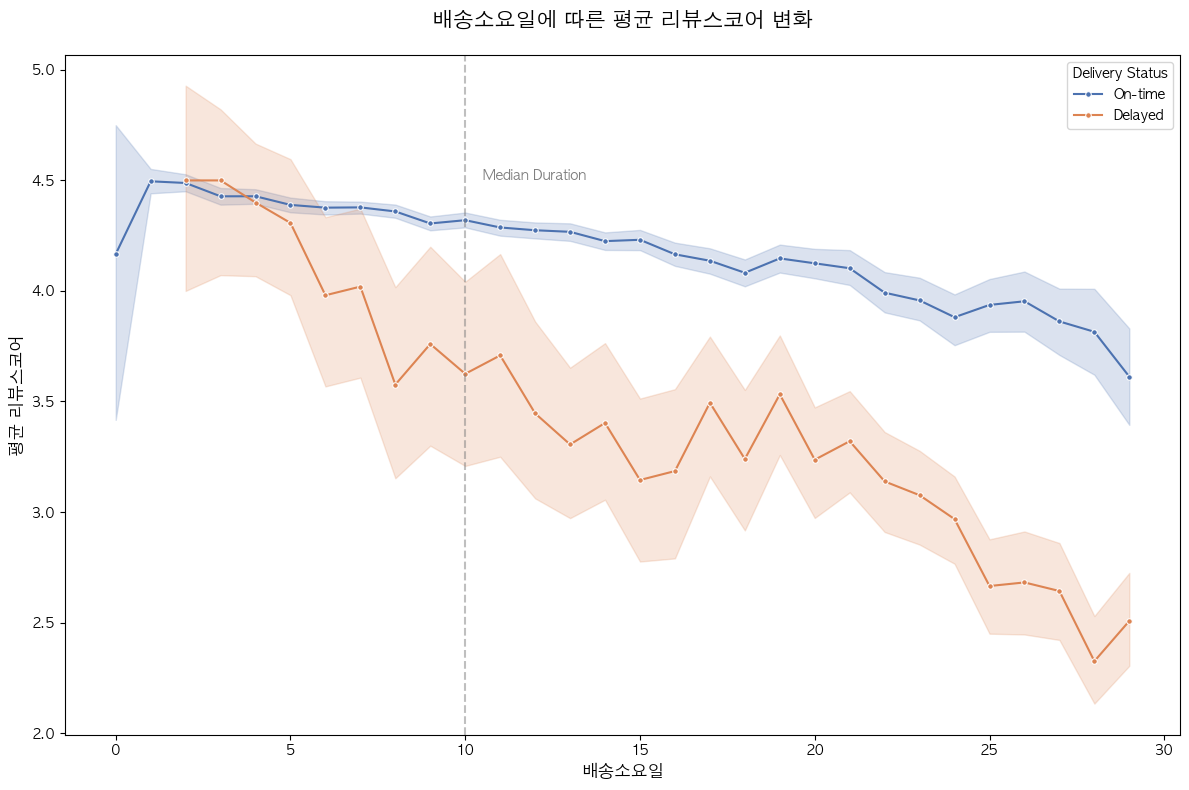

In [5053]:
# 1. 시각화 데이터 준비 (이상치 제거 - 상위 95% 수준)
upper_limit = df2['delivery_days'].quantile(0.95)
plot_data = df2[df2['delivery_days'] <= upper_limit].copy()

# 2. 범례(Legend)를 위한 지연 여부 라벨링
plot_data['status'] = plot_data['is_delayed'].map({1: 'Delayed', 0: 'On-time'})

# 3. 시각화
plt.figure(figsize=(12, 8))
sns.lineplot(data=plot_data, x='delivery_days', y='review_score', 
             hue='status', palette=['#4C72B0', "#DD8452"], 
             marker='o', markersize=4, errorbar=('ci', 95))

# 4. 그래프 디테일 설정
plt.title("배송소요일에 따른 평균 리뷰스코어 변화", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("배송소요일", fontsize=12)
plt.ylabel("평균 리뷰스코어", fontsize=12)
plt.legend(title="Delivery Status", frameon=True)

# 5. 인사이트 강화를 위한 수직선 (예: 전체 평균 소요일)
plt.axvline(df2['delivery_days'].median(), color='gray', linestyle='--', alpha=0.5)
plt.text(df2['delivery_days'].median() + 0.5, 4.5, 'Median Duration', color='gray', fontsize=10)

plt.tight_layout()
plt.show()

지연된 그룹과 정시에 도착한 그룹 두가지로 나누어 실제 배송소요일에 따른 리뷰스코어 변화를 확인해보았다

지연된 그룹에서는 실제 배송소요일이 중앙값보다 적었음에도, 정시에 도착한 그룹보다 일찍 도착했음에도 이와는 상관없이 리뷰 스코어가 낮게 나온 것을 볼 수 있다

이를 통해 브라질 Olist 입점 판매자들은 예상도착일(estimated)을 고의적으로라도 넉넉하게 잡아서 혹시나 발생할 수도 있는 지연 문제를 예방하여야 한다

하지만 그 전에..
고객들은 예상배송소요일수가 길더라도 이는 리뷰 스코어에 영향을 미치지 않는지 확인해볼 필요가 있어보인다.

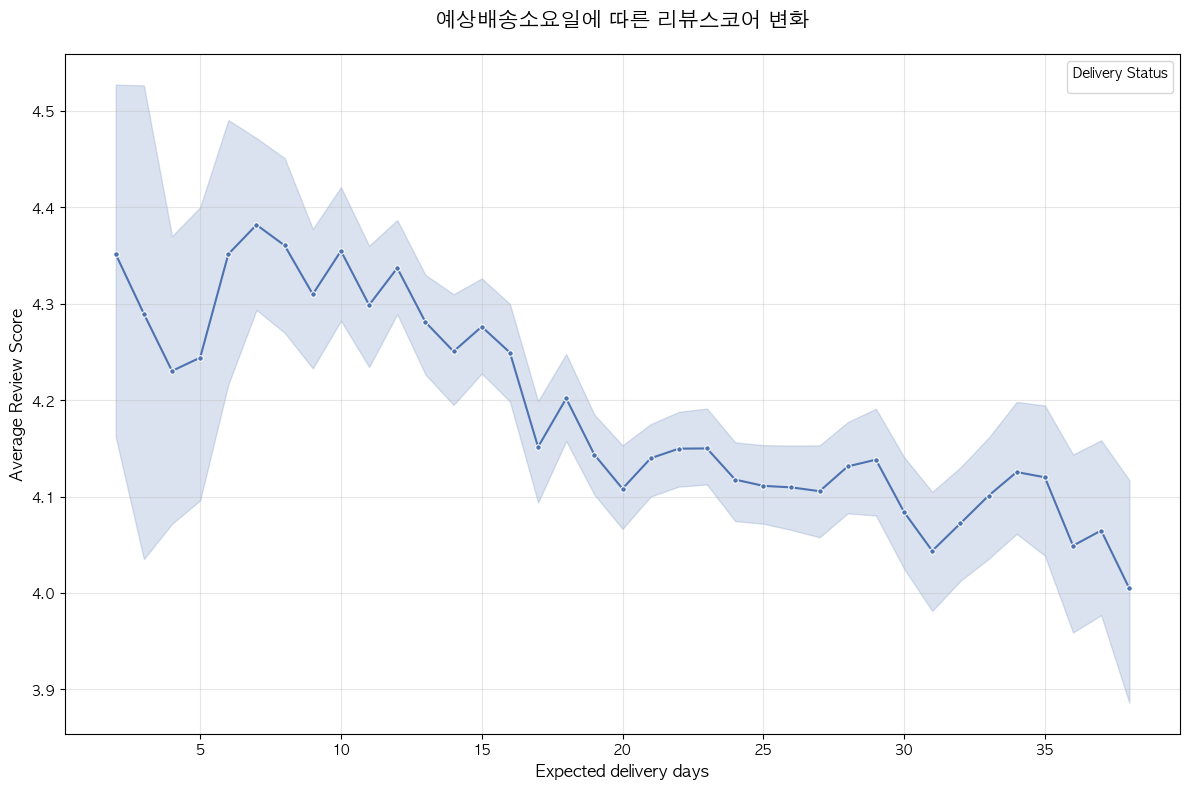

In [5054]:
# 예상배송소요일(expected_delivery_days)에 따른 리뷰스코어 변화 추이 시각화
upper_limit = df2['expected_delivery_days'].quantile(0.95) # 이상치 제거 - 상위 95% 수준
plot_data = df2[df2['expected_delivery_days'] <= upper_limit].copy()

plt.figure(figsize=(12, 8))
sns.lineplot(data=plot_data, x='expected_delivery_days', y='review_score', 
             marker='o', markersize=4, color='#4C72B0', errorbar=('ci', 95))

plt.title("예상배송소요일에 따른 리뷰스코어 변화", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Expected delivery days", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)
plt.legend(title="Delivery Status", frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

이에 따라 예상배송일을 길게 잡아도 이에 따른 리뷰스코어에 대한 영향은 크지 않다.

(위에서 구한 스피어만 상관계수를 확인하더라도 [expected_delivery_days] -0.056로 미미한 상관관계 수준)

지연이 발생하지 않도록 예상배송일을 의도적으로 길게 잡는 방법이 효과적일 것이다. (????)

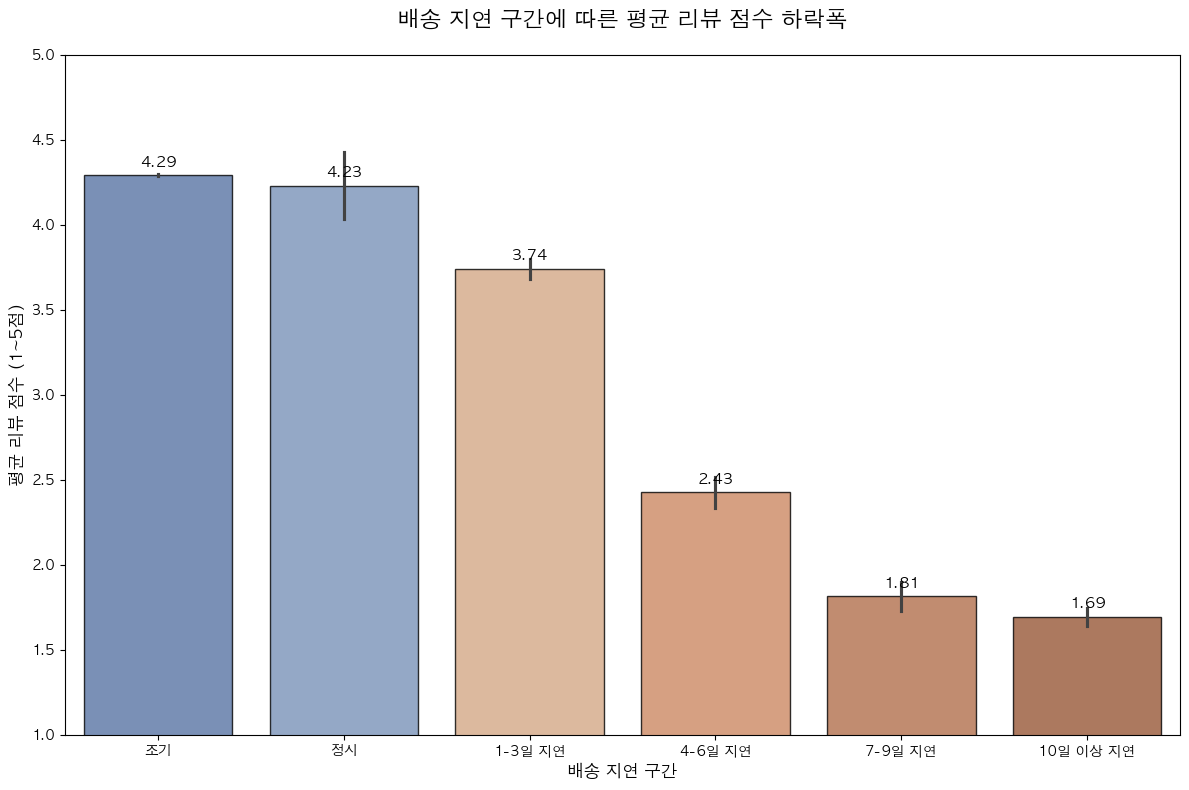

In [5055]:
# 배송 지연 구간별 평점 하락폭 분석 (Bar)
# delay_days: 양수면 조기 도착, 음수면 지연 도착

# 1. 구간 순서와 색상을 1:1로 매칭하는 딕셔너리 생성
order = ['조기', '정시', '1-3일 지연', '4-6일 지연', '7-9일 지연', '10일 이상 지연']
my_palette = {
    '조기': "#4C72B0",           # 블루
    '정시': "#7091C2",           # 연한 블루
    '1-3일 지연': "#E1A679",      # 연한 오렌지
    '4-6일 지연': "#DD8452",      # 오렌지
    '7-9일 지연': "#C36A3B",      # 진한 오렌지
    '10일 이상 지연': "#A85227"    # 레드/브라운
}

plt.figure(figsize=(12, 8))

# 2. barplot 그리기
sns.barplot(
    data=df2, 
    x='delay_days_cat', 
    y='review_score', 
    order=order, 
    palette=my_palette,     
    hue='delay_days_cat',   
    legend=False,            
    edgecolor='black',
    alpha=0.8
)

# 3. 그래프 디테일 (나머지는 동일)
plt.title('배송 지연 구간에 따른 평균 리뷰 점수 하락폭', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('배송 지연 구간', fontsize=12)
plt.ylabel('평균 리뷰 점수 (1~5점)', fontsize=12)
plt.ylim(1, 5)

# 값 표시 추가
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [5056]:
df2['delay_days_cat'].value_counts()

delay_days_cat
조기           70402
1-3일 지연       2061
10일 이상 지연     1940
4-6일 지연       1094
7-9일 지연        990
정시             140
Name: count, dtype: int64

In [5057]:
delayed_dispatch = df2[df2['is_delayed'] == 1]['dispatch_days']
not_delayed_dispatch = df2[df2['is_delayed'] == 0]['dispatch_days']

stat_d, p_d = stats.shapiro(delayed_dispatch)
stat_nd, p_nd = stats.shapiro(not_delayed_dispatch)
print(f"delayed_dispatch의 p-value: {p_d}")
print(f"not_delayed_dispatch의 p-value: {p_nd}")
print("두 집단의 p-value가 0.05 미만이므로 정규성을 만족하지 못하므로 맨휘트니-U검정을 해야한다")

delayed_dispatch의 p-value: 2.1235277939238698e-76
not_delayed_dispatch의 p-value: 1.2280919877500754e-133
두 집단의 p-value가 0.05 미만이므로 정규성을 만족하지 못하므로 맨휘트니-U검정을 해야한다


In [5058]:
u_stat, u_p = stats.mannwhitneyu(delayed_dispatch, not_delayed_dispatch, alternative="greater")
print(f"맨휘트니-U검정 결과 p-value: {u_p}") 
print("p-value가 0.05 미만이므로 지연배송의 출고소요일이 정상/조기배송보다 크다")

맨휘트니-U검정 결과 p-value: 0.0
p-value가 0.05 미만이므로 지연배송의 출고소요일이 정상/조기배송보다 크다


In [5059]:
# 비모수 효과크기 rank-biserial correlation
r_rb = pg.mwu(delayed_dispatch, not_delayed_dispatch)
display(r_rb)
# U_val	alternative	p_val	RBC	CLES
# MWU	279262877.5	two-sided	0.0	0.301172	0.650586

print(r_rb['RBC'].values[0]) # 효과크기가 중간이다!
print("RBC 효과크기가 0.3 이상으로 중간정도이다")
print("CLES가 0.65라는 것은 지연")

,U_val,alternative,p_val,RBC,CLES
MWU,279262877.5,two-sided,0.0,0.301172,0.650586


0.3011724315964892
RBC 효과크기가 0.3 이상으로 중간정도이다
CLES가 0.65라는 것은 지연


=== 지연 여부에 따른 판매자 출고 시간 분석 ===
정상/조기 배송 건의 평균 출고 시간: 2.50일
지연 배송 건의 평균 출고 시간: 5.40일
차이: 지연된 주문은 평균적으로 2.89일 더 늦게 출고됨


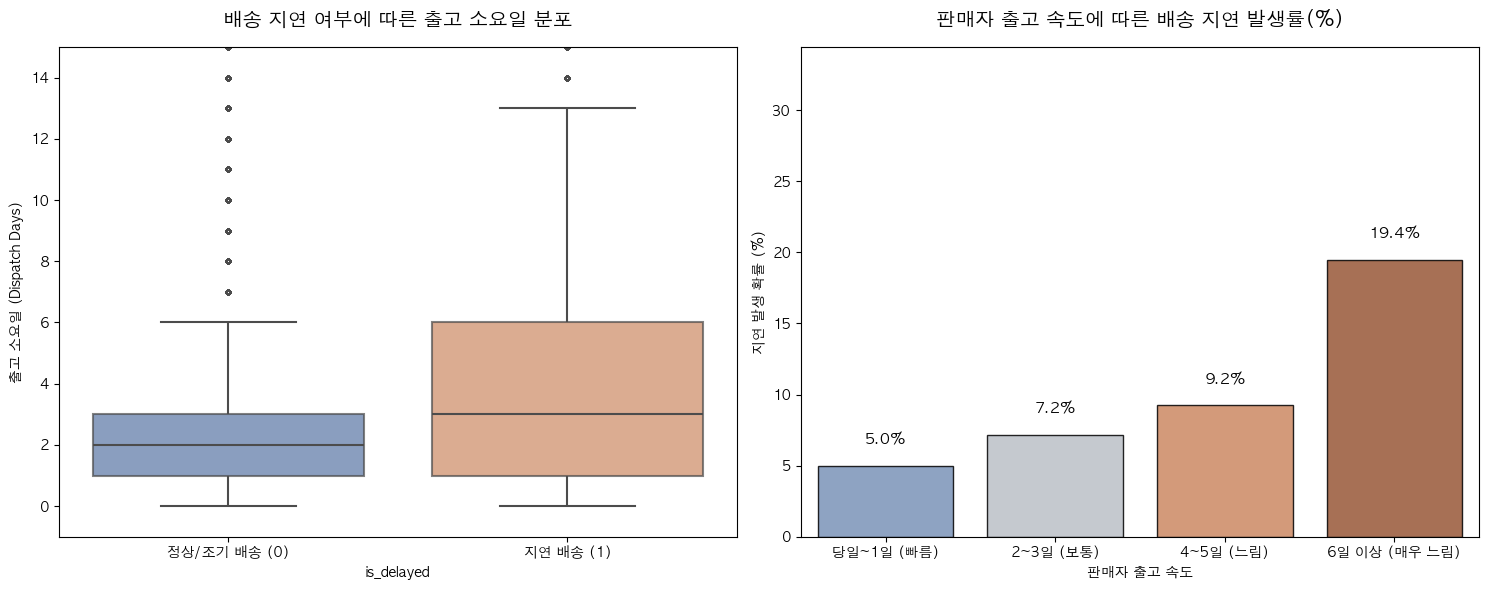

In [5060]:
print("=== 지연 여부에 따른 판매자 출고 시간 분석 ===")
print(f"정상/조기 배송 건의 평균 출고 시간: {not_delayed_dispatch.mean():.2f}일")
print(f"지연 배송 건의 평균 출고 시간: {delayed_dispatch.mean():.2f}일")
print(f"차이: 지연된 주문은 평균적으로 {delayed_dispatch.mean() - not_delayed_dispatch.mean():.2f}일 더 늦게 출고됨")

# 3. 출고 소요일 구간(카테고리)화 하여 지연 발생 확률(Delay Rate) 계산
# 구간 설정: 0~1일(빠름), 2~3일(보통), 4~5일(느림), 6일 이상(매우 느림)
bins = [-np.inf, 1, 3, 5, np.inf]
labels = ['당일~1일 (빠름)', '2~3일 (보통)', '4~5일 (느림)', '6일 이상 (매우 느림)']
df2['dispatch_speed'] = pd.cut(df2['dispatch_days'], bins=bins, labels=labels)

# 구간별 지연율 계산 (지연된 건수 / 전체 건수 * 100)
delay_rate = df2.groupby('dispatch_speed')['is_delayed'].mean() * 100

plt.rc('font', family='AppleGothic') 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 컬러 팔레트 정의
# 0: 블루(정상), 1: 오렌지(지연)
status_palette = {0: "#4C72B0", 1: "#DD8452"}
# 지연율 팔레트: 빠름(연한 블루) -> 매우 느림(짙은 오렌지/레드)
rate_palette = ["#7091C2", "#B9C0C9", "#DD8452", "#A85227"]

# [왼쪽] 배송 지연 여부에 따른 출고 소요일 분포 (Boxplot)
sns.boxplot(
    data=df2, 
    x='is_delayed', 
    y='dispatch_days', 
    ax=axes[0], 
    palette=status_palette,
    hue='is_delayed',
    legend=False,
    boxprops={'alpha': 0.7}, 
    linewidth=1.5,
    fliersize=3
)
axes[0].set_title('배송 지연 여부에 따른 출고 소요일 분포', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['정상/조기 배송 (0)', '지연 배송 (1)'])
axes[0].set_ylabel('출고 소요일 (Dispatch Days)')
axes[0].set_ylim(-1, 15) 

# [오른쪽] 출고 속도 구간별 배송 지연 발생률 (Barplot)
sns.barplot(
    x=delay_rate.index, 
    y=delay_rate.values, 
    ax=axes[1], 
    palette=rate_palette,
    hue=delay_rate.index,
    dodge=False,
    legend=False,
    edgecolor='black',
    alpha=0.85
)
axes[1].set_title('판매자 출고 속도에 따른 배송 지연 발생률(%)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('지연 발생 확률 (%)')
axes[1].set_xlabel('판매자 출고 속도')
axes[1].set_ylim(0, max(delay_rate.values) + 15) # 텍스트 공간 확보

# 막대 그래프 위에 퍼센트(%) 텍스트 추가
for i, v in enumerate(delay_rate.values):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [5061]:
df2['dispatch_speed'].value_counts()

dispatch_speed
당일~1일 (빠름)       34352
2~3일 (보통)        22510
4~5일 (느림)        10594
6일 이상 (매우 느림)     9171
Name: count, dtype: int64

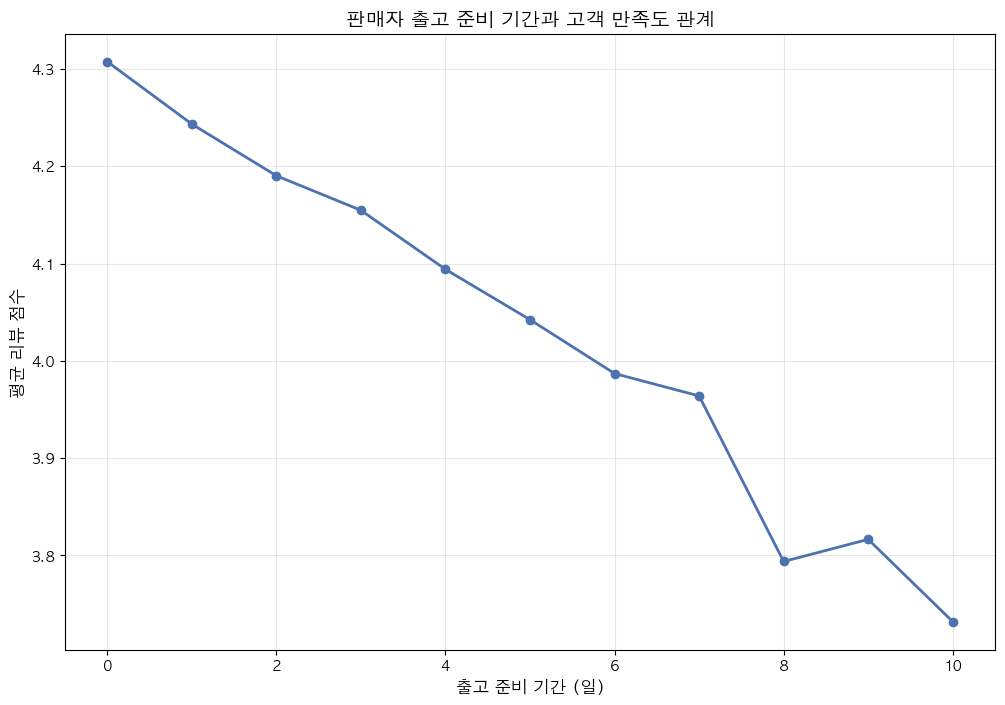

In [5062]:
# 출고 기간(0~10일)별 평균 리뷰 점수 시각화
plt.figure(figsize=(12, 8))
dispatch_perf = df2[df2['dispatch_days'].between(0, 10)].groupby('dispatch_days')['review_score'].mean()

plt.plot(dispatch_perf.index, dispatch_perf.values, marker='o', color='#4C72B0', linewidth=2)
plt.title('판매자 출고 준비 기간과 고객 만족도 관계', fontsize=14)
plt.xlabel('출고 준비 기간 (일)', fontsize=12)
plt.ylabel('평균 리뷰 점수', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

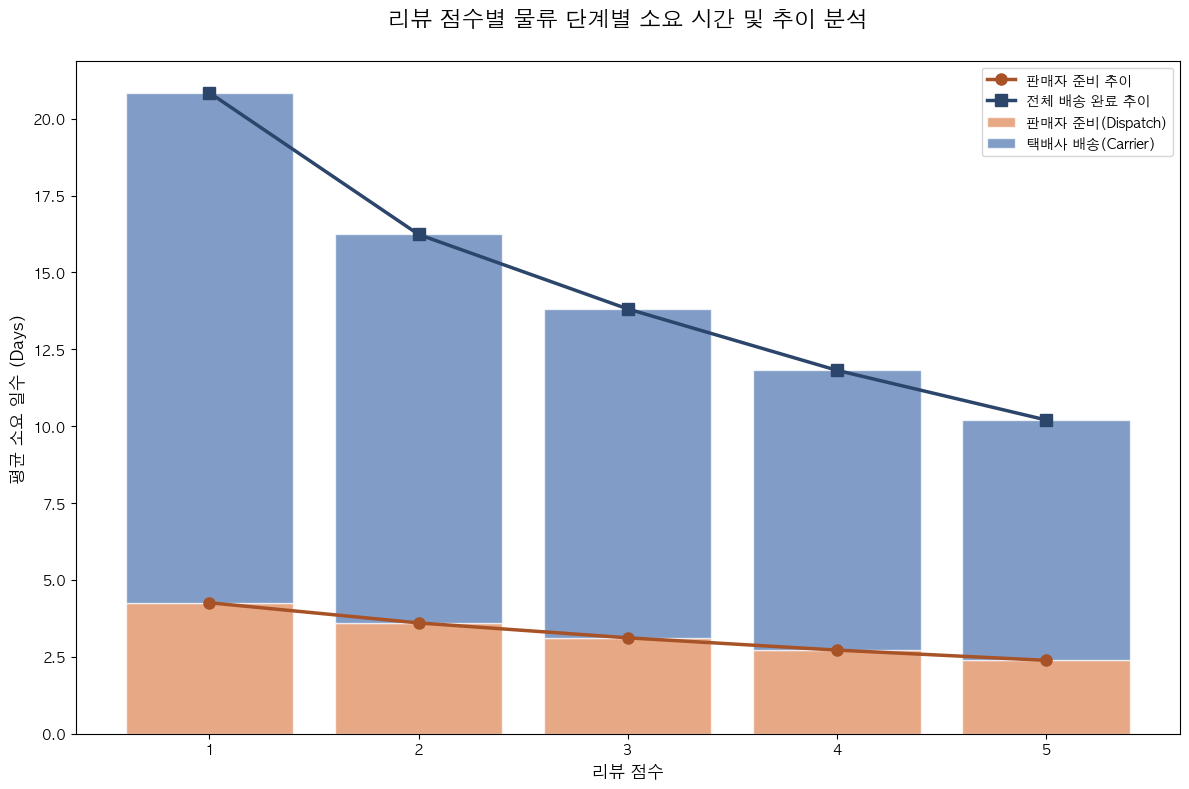

In [5063]:
import matplotlib.pyplot as plt

# 1. 폰트 및 스타일 설정 (Mac 환경 기준)
plt.rc('font', family='AppleGothic')
fig, ax = plt.subplots(figsize=(12, 8))

# 2. 데이터 준비
# 판매자 vs 택배사 책임 소재 분석
# 전체 배송일(delivery_days) = 출고 소요(dispatch_days) + 순수 배송(carrier_days)
df2['carrier_days'] = df2['delivery_days'] - df2['dispatch_days']

# 평점별 평균 소요 시간 비교
responsibility = df2.groupby(df2['review_score'].round().astype(int))[['dispatch_days', 'carrier_days']].mean()

# x축: 리뷰 점수 (1, 2, 3, 4, 5)
x = responsibility.index
y_dispatch = responsibility['dispatch_days']
y_carrier = responsibility['carrier_days']
y_total = y_dispatch + y_carrier  # 전체 높이 (택배사 막대의 끝점)

# 3. 누적 막대 그래프 그리기 (Background)
# 판매자 준비 기간 (바닥부터 시작)
ax.bar(x, y_dispatch, color="#DD8452", alpha=0.7, label='판매자 준비(Dispatch)', edgecolor='white')
# 택배사 배송 기간 (판매자 막대 위부터 시작)
ax.bar(x, y_carrier, bottom=y_dispatch, color="#4C72B0", alpha=0.7, label='택배사 배송(Carrier)', edgecolor='white')

# 4. 막대 끝점을 잇는 선 그리기 (Line Plot)
# 선 1: 판매자 준비 기간의 끝점 (첫 번째 세그먼트 상단)
ax.plot(x, y_dispatch, marker='o', linestyle='-', color='#A85227', 
        linewidth=2.5, markersize=8, label='판매자 준비 추이')

# 선 2: 전체 배송 완료 시점 (두 번째 세그먼트 상단 = 전체 높이)
ax.plot(x, y_total, marker='s', linestyle='-', color='#2B456B', 
        linewidth=2.5, markersize=8, label='전체 배송 완료 추이')

# 5. 세부 스타일링
plt.title('리뷰 점수별 물류 단계별 소요 시간 및 추이 분석', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('리뷰 점수', fontsize=12)
plt.ylabel('평균 소요 일수 (Days)', fontsize=12)

# 범례 설정
ax.legend(loc='upper right', frameon=True, fontsize=10)
plt.xticks(x)

plt.tight_layout()
plt.show()

In [5064]:
df2.columns

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_items_count', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat',
       'dispatch_speed', 'carrier_days'],
      dtype='str')

,customer_state,total_orders,delay_rate,avg_review_score
0,AC,81,2.857143,4.114286
1,AL,336,24.758842,3.832797
2,AM,121,3.738318,4.214953
3,AP,68,5.263158,4.228070
4,BA,2913,13.924543,3.940879
5,CE,1126,15.262636,3.948464
6,DF,1859,6.925881,4.133050
7,ES,1759,11.645570,4.082911
8,GO,1799,7.544757,4.096547
9,MA,613,19.818182,3.847273


array([<Axes: title={'center': '지역(State)별 배송 지연 발생률 (%) - 위험 지역부터 정렬'}, xlabel='customer_state', ylabel='delay_rate'>,
       <Axes: title={'center': '지역별 평균 리뷰 스코어 (지연 리스크와 평점의 관계 확인)'}, xlabel='customer_state', ylabel='avg_review_score'>],
      dtype=object)

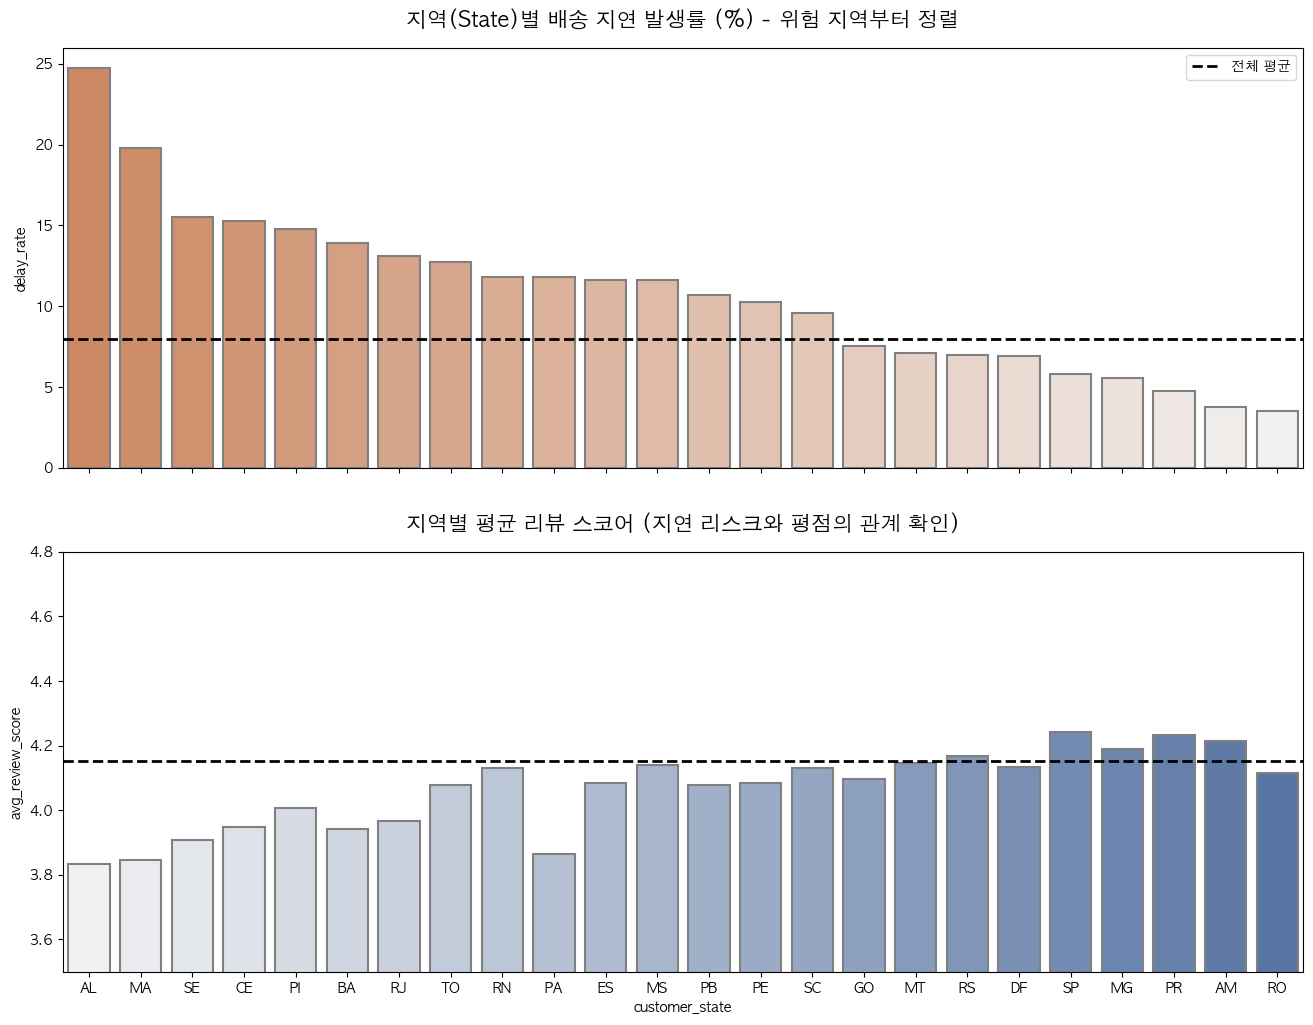

In [5065]:
# 한글 폰트 설정 (Mac 기준)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 및 전처리 (주문 건수가 너무 적은 노이즈 지역 필터링)
df_clean = df2.copy()

# 지역별 통계 계산
state_stats = df_clean.groupby('customer_state').agg(
    total_orders=('total_items_count', 'sum'),
    delay_rate=('is_delayed', lambda x: x.mean() * 100),    # 지연율(%)
    avg_review_score=('review_score', 'mean')               # 평균 리뷰 점수
).reset_index()

display(state_stats)

# 데이터 신뢰성을 위해 주문 건수 100건 이상인 지역(State)만 분석
state_stats = state_stats[state_stats['total_orders'] > 100]

# 지연율이 높은 순서대로(내림차순) 정렬 
state_stats_sorted = state_stats.sort_values(by='delay_rate', ascending=False)

# 전체 평균 계산 (비교 기준선용)
overall_delay_rate = df_clean['is_delayed'].mean() * 100
overall_review_score = df_clean['review_score'].mean()

# 1. 그라데이션 팔레트 생성 (데이터 개수에 맞춰 설정)
n_states = len(state_stats_sorted)
orange_grad = sns.light_palette("#DD8452", n_colors=n_states, reverse=True)
blue_grad = sns.light_palette("#4C72B0", n_colors=n_states, reverse=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# [위쪽 그래프] 지역별 배송 지연율 (%)
sns.barplot(
    data=state_stats_sorted, 
    x='customer_state', 
    y='delay_rate', 
    ax=axes[0], 
    palette=orange_grad,
    hue='customer_state',
    legend=False,
    edgecolor='gray',      # 테두리 색상 설정 (검정이나 진한 회색 추천)
    linewidth=1.5          # 테두리 두께 설정
)
axes[0].set_title('지역(State)별 배송 지연 발생률 (%) - 위험 지역부터 정렬', fontsize=15, fontweight='bold', pad=15)
axes[0].axhline(overall_delay_rate, color='black', linestyle='--', linewidth=2, label='전체 평균')
axes[0].legend(loc='upper right')

# [아래쪽 그래프] 지역별 평균 리뷰 스코어
sns.barplot(
    data=state_stats_sorted, 
    x='customer_state', 
    y='avg_review_score', 
    ax=axes[1], 
    palette=blue_grad,
    order=state_stats_sorted['customer_state'],
    hue='customer_state',
    legend=False,
    edgecolor='gray',      # 테두리 색상 설정
    linewidth=1.5          # 테두리 두께 설정
)
axes[1].set_title('지역별 평균 리뷰 스코어 (지연 리스크와 평점의 관계 확인)', fontsize=15, fontweight='bold', pad=15)
axes[1].axhline(overall_review_score, color='black', linestyle='--', linewidth=2, label='전체 평균')
axes[1].set_ylim(3.5, 4.8) 
axes

,seller_state,total_orders,delay_rate,avg_review_score
0,AM,3,66.666667,2.333333
1,BA,503,5.504587,4.192661
2,CE,58,14.545455,4.272727
3,DF,705,6.356589,4.083721
4,ES,283,4.958678,4.140496
5,GO,417,4.359673,4.386921
6,MA,323,22.857143,4.022222
7,MG,6861,5.574684,4.231841
8,MS,39,7.894737,4.657895
9,MT,116,4.545455,4.209091


array([<Axes: title={'center': '지역(State)별 배송 지연 발생률 (%) - 위험 지역부터 정렬'}, xlabel='seller_state', ylabel='delay_rate'>,
       <Axes: title={'center': '지역별 평균 리뷰 스코어 (지연 리스크와 평점의 관계 확인)'}, xlabel='seller_state', ylabel='avg_review_score'>],
      dtype=object)

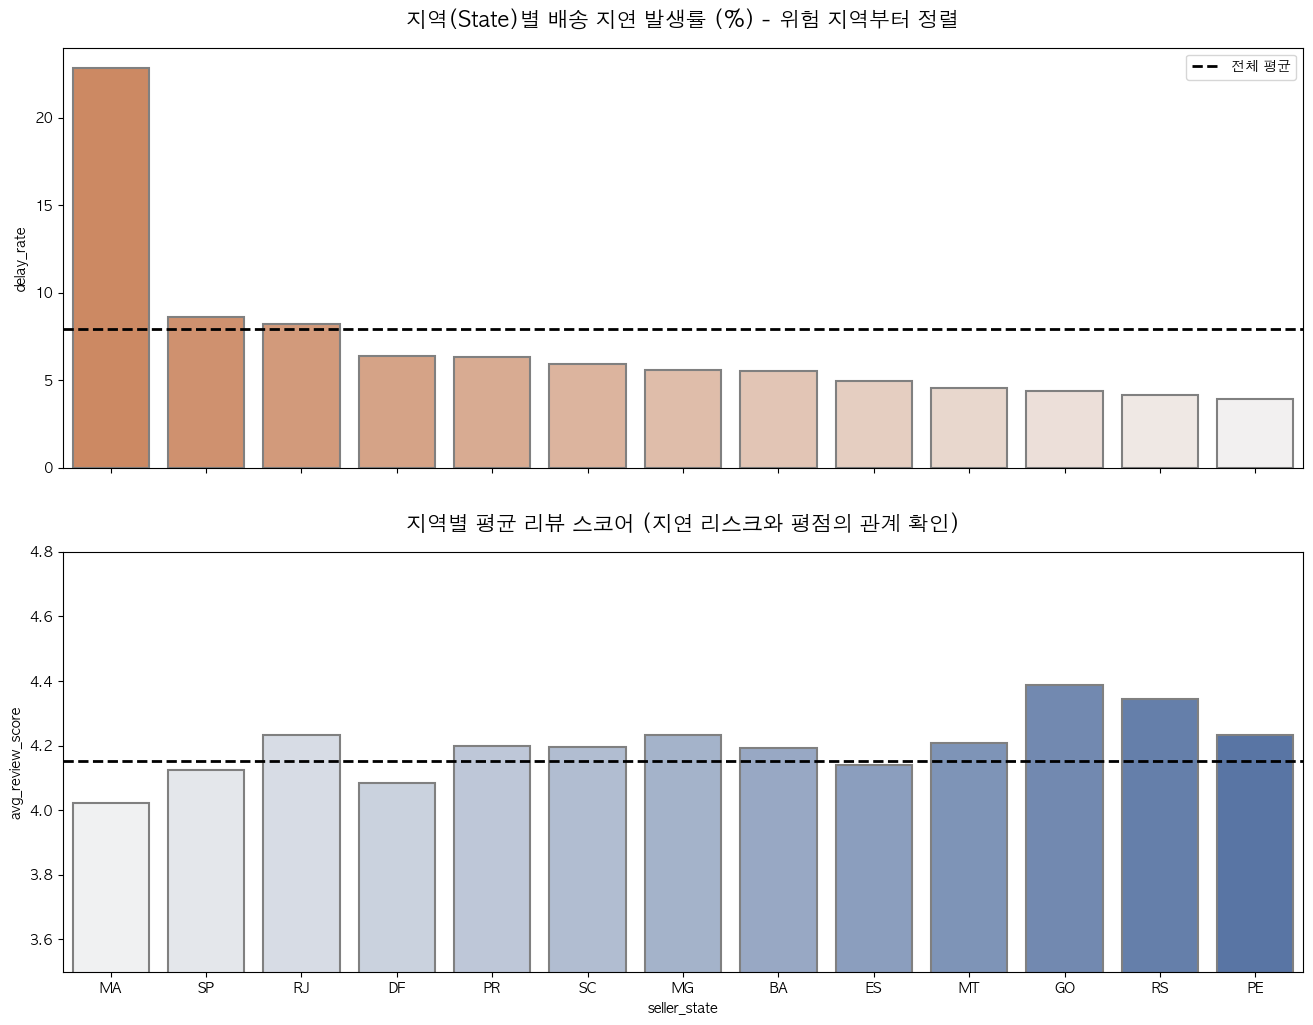

In [5066]:
# 한글 폰트 설정 (Mac 기준)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 및 전처리 (주문 건수가 너무 적은 노이즈 지역 필터링)
df_clean = df2.copy()

# 지역별 통계 계산
state_stats = df_clean.groupby('seller_state').agg(
    total_orders=('total_items_count', 'sum'),
    delay_rate=('is_delayed', lambda x: x.mean() * 100),    # 지연율(%)
    avg_review_score=('review_score', 'mean')               # 평균 리뷰 점수
).reset_index()

display(state_stats)

# 데이터 신뢰성을 위해 주문 건수 100건 이상인 지역(State)만 분석
state_stats = state_stats[state_stats['total_orders'] > 100]

# 지연율이 높은 순서대로(내림차순) 정렬 
state_stats_sorted = state_stats.sort_values(by='delay_rate', ascending=False)

# 전체 평균 계산 (비교 기준선용)
overall_delay_rate = df_clean['is_delayed'].mean() * 100
overall_review_score = df_clean['review_score'].mean()

# 1. 그라데이션 팔레트 생성 (데이터 개수에 맞춰 설정)
n_states = len(state_stats_sorted)
orange_grad = sns.light_palette("#DD8452", n_colors=n_states, reverse=True)
blue_grad = sns.light_palette("#4C72B0", n_colors=n_states, reverse=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# [위쪽 그래프] 지역별 배송 지연율 (%)
sns.barplot(
    data=state_stats_sorted, 
    x='seller_state', 
    y='delay_rate', 
    ax=axes[0], 
    palette=orange_grad,
    hue='seller_state',
    legend=False,
    edgecolor='gray',      # 테두리 색상 설정 (검정이나 진한 회색 추천)
    linewidth=1.5          # 테두리 두께 설정
)
axes[0].set_title('지역(State)별 배송 지연 발생률 (%) - 위험 지역부터 정렬', fontsize=15, fontweight='bold', pad=15)
axes[0].axhline(overall_delay_rate, color='black', linestyle='--', linewidth=2, label='전체 평균')
axes[0].legend(loc='upper right')

# [아래쪽 그래프] 지역별 평균 리뷰 스코어
sns.barplot(
    data=state_stats_sorted, 
    x='seller_state', 
    y='avg_review_score', 
    ax=axes[1], 
    palette=blue_grad,
    order=state_stats_sorted['seller_state'],
    hue='seller_state',
    legend=False,
    edgecolor='gray',      # 테두리 색상 설정
    linewidth=1.5          # 테두리 두께 설정
)
axes[1].set_title('지역별 평균 리뷰 스코어 (지연 리스크와 평점의 관계 확인)', fontsize=15, fontweight='bold', pad=15)
axes[1].axhline(overall_review_score, color='black', linestyle='--', linewidth=2, label='전체 평균')
axes[1].set_ylim(3.5, 4.8) 
axes

In [5067]:
df2.columns

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_items_count', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat',
       'dispatch_speed', 'carrier_days'],
      dtype='str')

In [5068]:
df2[df2['seller_state']=='SE']

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed,delay_days_cat,dispatch_speed,carrier_days
24295,24436,8d25f73f2fe9c225dff2232fd1e7c89b,626478b0f57ed4bdf6f462568f16d5d5,2017-01-30 23:20:41,2017-02-01 04:36:09,2017-02-02 11:43:39,2017-02-15 13:38:51,2017-03-14,5d3352f7a8f2f9e5d159f83b645a170f,castanhal,PA,1,12a3f3a8ef6c5e3c29c88e670fd61ee9,c53bcd3be457a342a97e39e5a9f0be22,2017-02-03 23:20:41,119.9,26.00,1,NaN,NaN,bed_bath_table,neopolis,SE,monday,1,2017,1,2,15,42,-26.4,-26,0,조기,2~3일 (보통),13
36009,36236,566c54af4e636ee14ef5e97398919a60,0554357bede8e7adab8e4d3a88652483,2018-07-18 16:55:20,2018-07-19 03:02:32,2018-07-24 11:15:00,2018-08-02 20:18:56,2018-08-20,0f22608086c231ee99c1a06ea07141a7,castelo,ES,1,b370dd237db6a8a0bd74a6da9e367a80,c53bcd3be457a342a97e39e5a9f0be22,2018-07-25 03:02:32,89.9,42.91,5,NaN,NaN,bed_bath_table,neopolis,SE,wednesday,7,2018,0,5,15,32,-17.2,-17,0,조기,4~5일 (느림),10
32663,32865,c7aa0d557dc01880717bbcce8c72640e,cc492e0bf69baaceb9f1e1d432e63960,2017-11-05 16:14:34,2017-11-05 16:26:44,2017-11-08 20:28:48,2017-11-20 22:48:45,2017-12-06,073667f98c8956621ffdacb34d7ab922,ipubi,PE,2,0d146484c69d613fe015c0229056b065,c53bcd3be457a342a97e39e5a9f0be22,2017-11-09 16:26:44,130.8,46.95,1,NaN,Falta receber o protetor de porta e os jogos d...,furniture_decor,neopolis,SE,sunday,11,2017,0,3,15,30,-15.0,-15,0,조기,2~3일 (보통),12
92675,93298,c2b1c0fcdd5d03ed47f2b02494cdbc63,78078075e327093313db151ad0db0e38,2017-11-30 13:31:19,2017-11-30 13:52:17,2017-11-30 23:16:46,2017-12-12 20:58:50,2017-12-28,1c084ba784990c612f368517963f795c,sao paulo,SP,1,05c2523e08c5262f1ee172b332c3ea44,4b39558c138930b9e5489c93b6df5fe3,2017-12-06 13:52:17,189.0,22.12,5,NaN,NaN,computers_accessories,aracaju,SE,thursday,11,2017,0,0,12,27,-15.1,-15,0,조기,당일~1일 (빠름),12
9386,9434,153b80864a22f0638fef4339488a2cf3,3465815678642fddd150c74f20f98f0e,2017-11-15 00:16:15,2017-11-16 00:10:50,2017-11-16 21:14:41,2017-11-28 19:33:58,2017-12-13,22f845998f64187faf181b128bf035fb,siqueira campos,PR,2,05c2523e08c5262f1ee172b332c3ea44,4b39558c138930b9e5489c93b6df5fe3,2017-11-22 00:10:50,378.0,43.36,5,NaN,NaN,computers_accessories,aracaju,SE,wednesday,11,2017,0,1,13,27,-14.2,-14,0,조기,당일~1일 (빠름),12
31187,31377,b896461e3ed46fe0c2f27a21c5a895aa,91e93abb370cd3dc6af2a46b988c593f,2017-05-31 11:55:59,2017-05-31 13:07:27,2017-06-02 05:19:45,2017-06-08 14:33:14,2017-07-03,b9a1e1269bd753aea97e6d559acc1eee,rio de janeiro,RJ,1,32ee3f4e2493045726807808d7abbab6,c53bcd3be457a342a97e39e5a9f0be22,2017-06-06 12:32:46,89.9,38.18,4,NaN,NaN,bed_bath_table,neopolis,SE,wednesday,5,2017,0,1,8,32,-24.4,-24,0,조기,당일~1일 (빠름),7
12615,12677,d1574473ad1d4a427f66f0d1d6bf7985,e1848973a1112ee837932651fd29470f,2018-01-14 16:43:17,2018-01-16 13:55:39,2018-01-17 12:53:34,2018-01-30 00:35:11,2018-02-09,e998fe2c90ef3b9651190d78d026eea9,itumbiara,GO,1,0c35aab0ba0e5a36a652fc2b10f2c102,4b39558c138930b9e5489c93b6df5fe3,2018-01-22 13:55:39,360.8,36.33,5,NaN,NaN,industry_commerce_and_business,aracaju,SE,sunday,1,2018,1,2,15,25,-10.0,-10,0,조기,2~3일 (보통),13


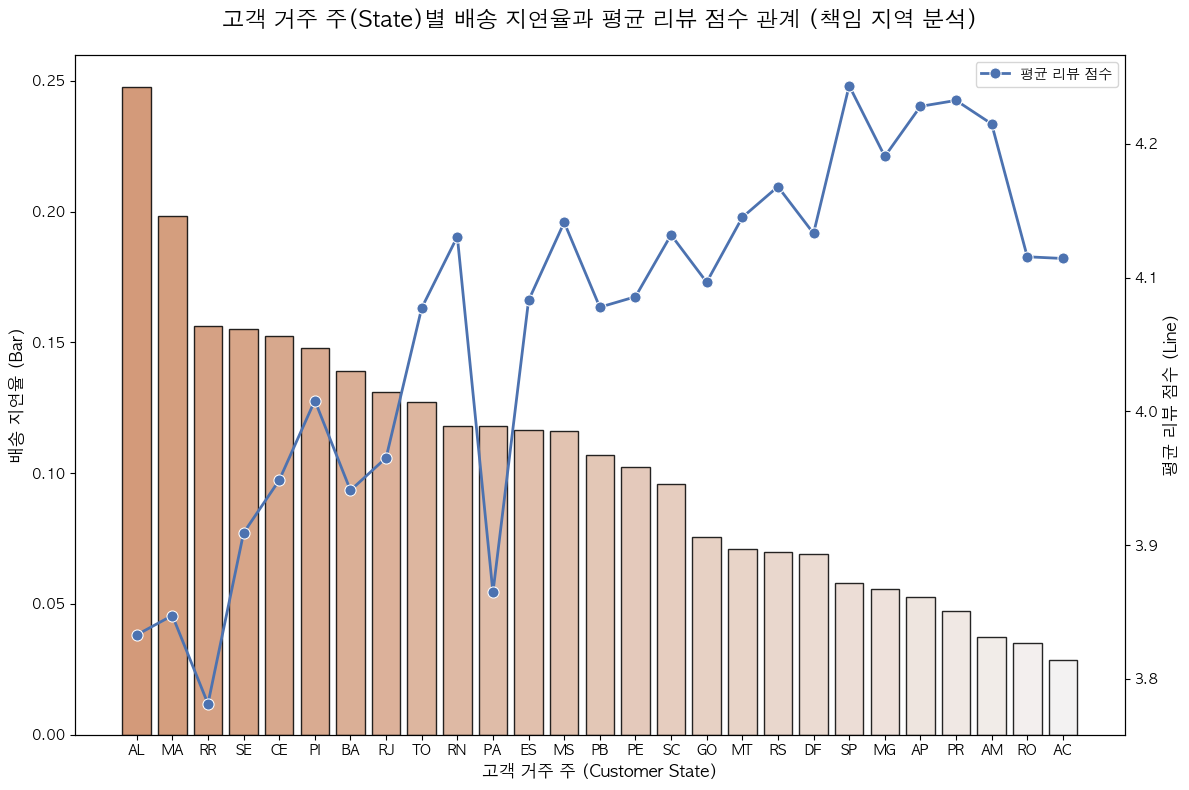

In [5069]:
# 고객 거주 지역별(State) 물류 효율 및 만족도 분석

# 1. 폰트 및 스타일 설정 (Mac 환경 최적화)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 분석
state_analysis = df2.groupby('customer_state').agg({
    'is_delayed': 'mean',
    'review_score': 'mean'
}).sort_values(by='is_delayed', ascending=False)

# 3. 그라데이션 팔레트 생성 (지연율 순서대로 진함 -> 연함)
n_states = len(state_analysis)
orange_grad = sns.light_palette("#DD8452", n_colors=n_states, reverse=True)

# 4. 도화지 및 이중 축 설정
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx() # x축을 공유하는 두 번째 y축 생성

# [BarPlot] 배송 지연율 (그라데이션 + 검정 테두리 적용)
sns.barplot(
    x=state_analysis.index, 
    y=state_analysis['is_delayed'], 
    ax=ax1, 
    palette=orange_grad,
    hue=state_analysis.index, 
    dodge=False,           
    legend=False,
    edgecolor='black',      
    linewidth=1.0,       
    alpha=0.85
)

# [LinePlot] 평균 리뷰 점수 (블루 계열 유지)
sns.lineplot(
    x=state_analysis.index, 
    y=state_analysis['review_score'], 
    ax=ax2, 
    color="#4C72B0", 
    marker='o', 
    markersize=8,
    linewidth=2, 
    label='평균 리뷰 점수'
)

# 5. 세부 디자인 설정
ax1.set_title('고객 거주 주(State)별 배송 지연율과 평균 리뷰 점수 관계 (책임 지역 분석)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('고객 거주 주 (Customer State)', fontsize=12)
ax1.set_ylabel('배송 지연율 (Bar)', fontsize=12, fontweight='bold')
ax2.set_ylabel('평균 리뷰 점수 (Line)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

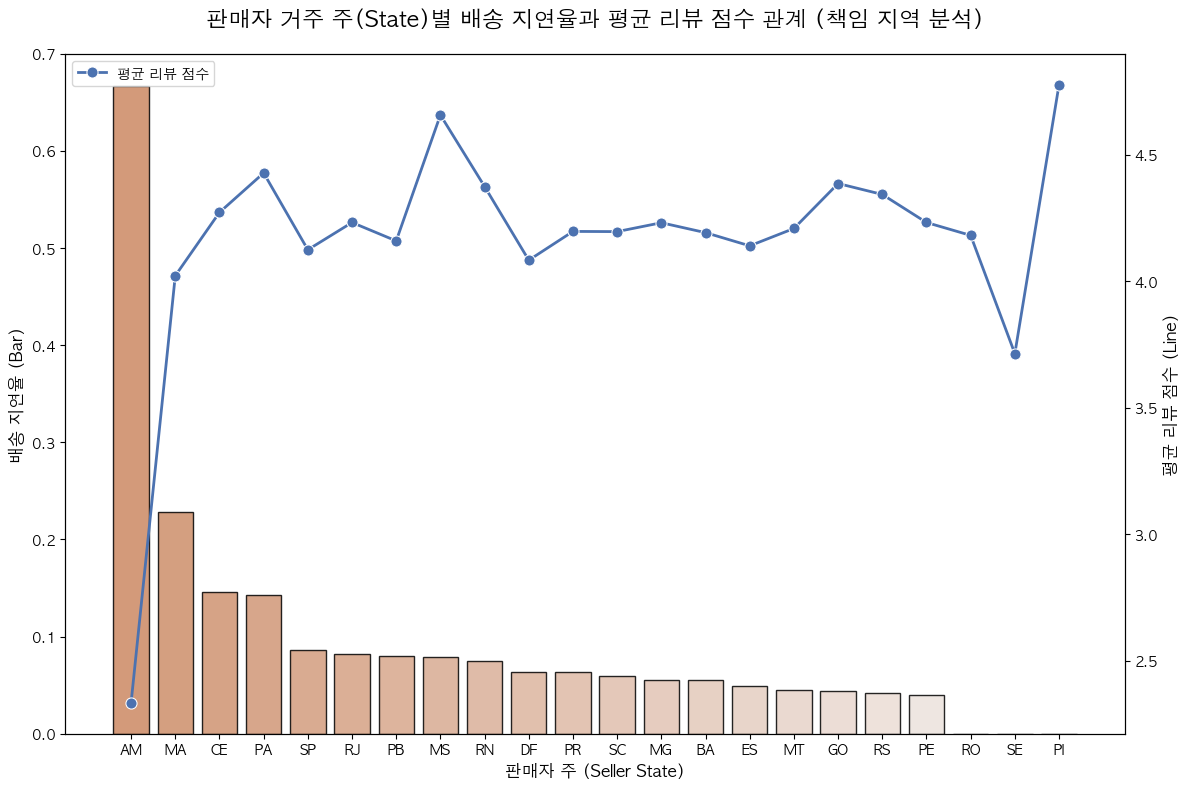

In [5070]:
# 판매자 지역별(State) 물류 효율 및 만족도 분석

# 1. 폰트 및 스타일 설정 (Mac 환경 최적화)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 분석
state_analysis = df2.groupby('seller_state').agg({
    'is_delayed': 'mean',
    'review_score': 'mean'
}).sort_values(by='is_delayed', ascending=False)

# 3. 그라데이션 팔레트 생성 (지연율 순서대로 진함 -> 연함)
n_states = len(state_analysis)
orange_grad = sns.light_palette("#DD8452", n_colors=n_states, reverse=True)

# 4. 도화지 및 이중 축 설정
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx() # x축을 공유하는 두 번째 y축 생성

# [BarPlot] 배송 지연율 (그라데이션 + 검정 테두리 적용)
sns.barplot(
    x=state_analysis.index, 
    y=state_analysis['is_delayed'], 
    ax=ax1, 
    palette=orange_grad,
    hue=state_analysis.index, 
    dodge=False,           
    legend=False,
    edgecolor='black',      
    linewidth=1.0,       
    alpha=0.85
)

# [LinePlot] 평균 리뷰 점수 (블루 계열 유지)
sns.lineplot(
    x=state_analysis.index, 
    y=state_analysis['review_score'], 
    ax=ax2, 
    color="#4C72B0", 
    marker='o', 
    markersize=8,
    linewidth=2, 
    label='평균 리뷰 점수'
)

# 5. 세부 디자인 설정
ax1.set_title('판매자 거주 주(State)별 배송 지연율과 평균 리뷰 점수 관계 (책임 지역 분석)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('판매자 주 (Seller State)', fontsize=12)
ax1.set_ylabel('배송 지연율 (Bar)', fontsize=12, fontweight='bold')
ax2.set_ylabel('평균 리뷰 점수 (Line)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()